**======================================================================================================**
<p align="center"><b>PRE PROCESAMIENTO PROYECTO ANÁLISIS DE DATOS</b></p>

**======================================================================================================**
**Integrantes:** 
*   Vismark Abner Choque Cachi
*   Elizabeth Cusi Ancasi
  
**Materia: Analisis de Datos**  
**Docente: M.Sc. Madelina Loza Soliz**  
**Sigla: DAT-263**
**======================================================================================================**

In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", message="partition")
warnings.filterwarnings("ignore", category=UserWarning, module="numpy")

# **1) IMPORTACION DEL DATASET**

In [199]:
#COLUMNAS del dataset
examen = pd.read_excel('data/originales/examen_2.xlsx')
for i,valor in enumerate(examen.columns):
  print(i,valor)



0 Correo electrónico
1 Escriba su edad en años cumplidos
2 Genero al que pertenece
3 Estado Civil
4 En su casa usted dispone de computadora personal, laptop o Tablet?
5 En su casa usted dispone de:
6 Qué tipo de acceso a internet tiene desde su casa?
7 Tiene celular?
8 Tiene internet en el celular
9 Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?
10 Usted preferiría pasar los cursos de manera:
11 ¿Porqué?
12 Que plataforma utiliza para sus clases virtuales
13 En las sesiones on line de clases utiliza
14 Cuales son los medios de comunicación que utiliza para comunicarse con el docente:
15 Cantidad de materias que ha tomado hasta la fecha
16 Cantidad de materias aprobadas hasta la fecha
17 Las razones por la que aprobó sus materias son:
18 Cantidad de materias reprobadas hasta la fecha.
19 Las razones para reprobar fueron:
20 El nivel de aprendizaje que ha logrado fue (donde 1 es pésim

## **INFORMACION BASICA DEL DATASET**

In [200]:
examen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 23 columns):
 #   Column                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                   --------------  -----  
 0   Correo electrónico                                                                                                                                       909 non-null    object 
 1   Escriba su edad en años cumplidos                                                                                                                        909 non-null    object 
 2   Genero al que pertenece                                                                                                                                  909 non-n

# **2) CONVERSION DE TIPOS DE DATOS**

In [201]:
import pandas as pd
from tabulate import tabulate

df = examen.copy()

# -------------------------------------------------
# 2. Detectar variables numéricas y categóricas
# -------------------------------------------------
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# -------------------------------------------------
# 3. Tablas
# -------------------------------------------------

# Variables numéricas (solo nombre)
tabla_num = [[i+1, col] for i, col in enumerate(num_cols)]

# Variables categóricas (nombre + número de categorías únicas)
categorias_por_columna = df[cat_cols].nunique()
tabla_cat = [[i+1, col, categorias_por_columna[col]] for i, col in enumerate(cat_cols)]

print("\n===============================")
print("Variables Numéricas")
print("===============================")
print(tabulate(tabla_num, headers=["N°", "Columna"], tablefmt="pretty"))

print("\n\n\n===============================")
print("Variables Categóricas")
print("===============================")
print(tabulate(tabla_cat, headers=["N°", "Columna", "Categorías únicas"], tablefmt="pretty"))



Variables Numéricas
+----+---------------------------------------------------------------------------------------------------------------------------------------------------------+
| N° |                                                                         Columna                                                                         |
+----+---------------------------------------------------------------------------------------------------------------------------------------------------------+
| 1  | Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet? |
| 2  |                                                    Cantidad de materias que ha tomado hasta la fecha                                                    |
| 3  |                                                      Cantidad de materias aprobadas hasta la fecha                                                      |
| 4  |       

In [202]:

nombre_columnas_numericas = [
    'Escriba su edad en años cumplidos',
    'Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?',
    'Cantidad de materias que ha tomado hasta la fecha',
    'Cantidad de materias aprobadas hasta la fecha',
    'Cantidad de materias reprobadas hasta la fecha.',
    'El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):'
]

for col in nombre_columnas_numericas:
    if col in examen.columns:
        # Convierte a float primero por si hay decimales, luego a Int64 para mantener NaN
        examen[col] = pd.to_numeric(examen[col], errors='coerce').astype("Int64")


In [203]:
examen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 23 columns):
 #   Column                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                   --------------  -----  
 0   Correo electrónico                                                                                                                                       909 non-null    object 
 1   Escriba su edad en años cumplidos                                                                                                                        908 non-null    Int64  
 2   Genero al que pertenece                                                                                                                                  909 non-n

## **RESUMEN DE LOS DATOS**
Este bloque genera un **resumen estadístico completo** usando `describe(include='all')`, incluyendo columnas numéricas y categóricas.  
Luego se transpone (`.T`) para que cada columna del dataset aparezca como fila, facilitando la lectura.  
Finalmente, se agrega la columna `Tipo_dato` para mostrar el **tipo de dato de cada columna** (`int64`, `float64`, `object`).  

Este resumen permite **ver rápidamente estadísticas, valores únicos, frecuencia de los datos categóricos y el tipo de cada columna**, ayudando a entender mejor la estructura del dataset.

In [204]:
resumen = examen.describe(include='all')
# Transpuesta
resumen_T = resumen.T
resumen_T['Tipo_dato'] = resumen.dtypes
resumen_T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,Tipo_dato
Correo electrónico,909,909,lchural@fcpn.edu.bo,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Escriba su edad en años cumplidos,908.0,<NA>,<NA>,<NA>,22.896476,5.013352,12.0,20.0,22.0,25.0,55.0,Float64
Genero al que pertenece,909,2,Masculino,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Estado Civil,909,10,Soltero,877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
"En su casa usted dispone de computadora personal, laptop o Tablet?",905,2,Sí,774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
En su casa usted dispone de:,778,7,Laptop,409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Qué tipo de acceso a internet tiene desde su casa?,899,54,Modem WiFi,487,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Tiene celular?,903,2,Sí,893,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Tiene internet en el celular,885,2,Sí,847,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?,897.0,<NA>,<NA>,<NA>,2.960981,1.012001,1.0,2.0,3.0,4.0,5.0,Float64


## **ANÁLISIS GENERAL DEL CONJUNTO DE DATOS**

---

## 1. **DESCRIPCIÓN GENERAL**
- **Total de registros:** 909
- **Variables con datos faltantes:**
    - **Edad:** 908 registros válidos
    - **Materias aprobadas:** 821 registros válidos
- **Tipos de variables:**
    - **Categóricas:** Género, Estado Civil, etc.
    - **Numéricas:** Edad, Cantidad de materias, etc.
- **Valores atípicos detectados:**
    - **Edad:** desde 12 años (muy baja)
    - **Materias aprobadas:** -1 (valor negativo, probable error)

---

## 2. **DATOS DEMOGRÁFICOS**
- **Edad promedio:** 22.9 años  
- **Rango de edad:** 12 – 55 años  
- **Distribución de género:**
    - **Masculino:** 63%
    - **Femenino:** 37%
- **Estado civil:**
    - **Soltero:** 96%
    - **Otros:** 4%

---

## 3. **ACCESO A TECNOLOGÍA E INTERNET**
- **Computadoras/laptops/tablets:** 85%  
    - **Dispositivo más común:** Laptop
- **Acceso a internet:**
    - **Módem WiFi:** 54%
- **Teléfono celular:** 99%
- **Internet móvil:** 96%

---

## 4. **EXPERIENCIA EDUCATIVA VIRTUAL**
- **Puntuación promedio clases virtuales:** 2.96 / 5  
- **Desviación estándar:** 1.01  
- **Modalidad preferida:** Semipresencial (41%)  
- **Plataformas más utilizadas:**
    - **Google Classroom:** 59%
    - **Google Meet:** 43%
- **Canales más usados para comunicarse con docentes:** WhatsApp, Correo electrónico

---

## 5. **DESEMPEÑO ACADÉMICO**
- **Materias tomadas (promedio):** 17.6 (rango: 1 – 152)  
- **Materias aprobadas (promedio):** 12.6 (valor negativo detectado: -1)  
- **Materias reprobadas (promedio):** 5.7 (rango hasta 60)  
- **Razones más comunes:**
    - **Aprobar:** Atención y dedicación al estudio  
    - **Reprobar:** Algunos docentes no se les entiende bien
- **Nivel de aprendizaje percibido:** 3.31 / 5 (satisfacción moderada)


# **3) TRATAMIENTO DE DATOS FALTANTES**

En esta sección se identificarán los **valores faltantes** del dataset y se aplicarán las **estrategias necesarias para su manejo**, asegurando que los datos estén listos para el análisis.


## **CANTIDAD DE DATOS FALTANTES Y VACIOS**
Se tomaran en cuenta los datos faltantes y vacios(aquellos que esten ocupados por espacios)

In [205]:
#GENERACION DE UNA TABLA DE RESUMEN DE DATOS FALTANTES
datos_faltantes = pd.DataFrame(columns = ['COLUMNA','NAN','VACIOS','TOTAL_FALTANTES'],dtype = str)
for ids,colum in enumerate(examen.columns):
  cant_nan = examen[colum].isna().sum()
  if(examen[colum].dtype=='object'):
    cant_vacios = (examen[colum].astype(str).str.strip() == '').sum()
  else:
    cant_vacios = 0
  datos_faltantes.loc[ids,'COLUMNA'] = colum
  datos_faltantes.loc[ids,'NAN'] = cant_nan
  datos_faltantes.loc[ids,'VACIOS'] = cant_vacios
  datos_faltantes.loc[ids,'TOTAL_FALTANTES'] = cant_nan+cant_vacios


datos_faltantes



,COLUMNA,NAN,VACIOS,TOTAL_FALTANTES
0,Correo electrónico,0,0,0
1,Escriba su edad en años cumplidos,1,0,1
2,Genero al que pertenece,0,0,0
3,Estado Civil,0,0,0
4,En su casa usted dispone de computadora person...,4,0,4
5,En su casa usted dispone de:,131,0,131
6,Qué tipo de acceso a internet tiene desde su c...,10,0,10
7,Tiene celular?,6,0,6
8,Tiene internet en el celular,24,0,24
9,Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qu...,12,0,12


## **GRAFICO DE PORCENTAJE DATOS DE FALTANTES**


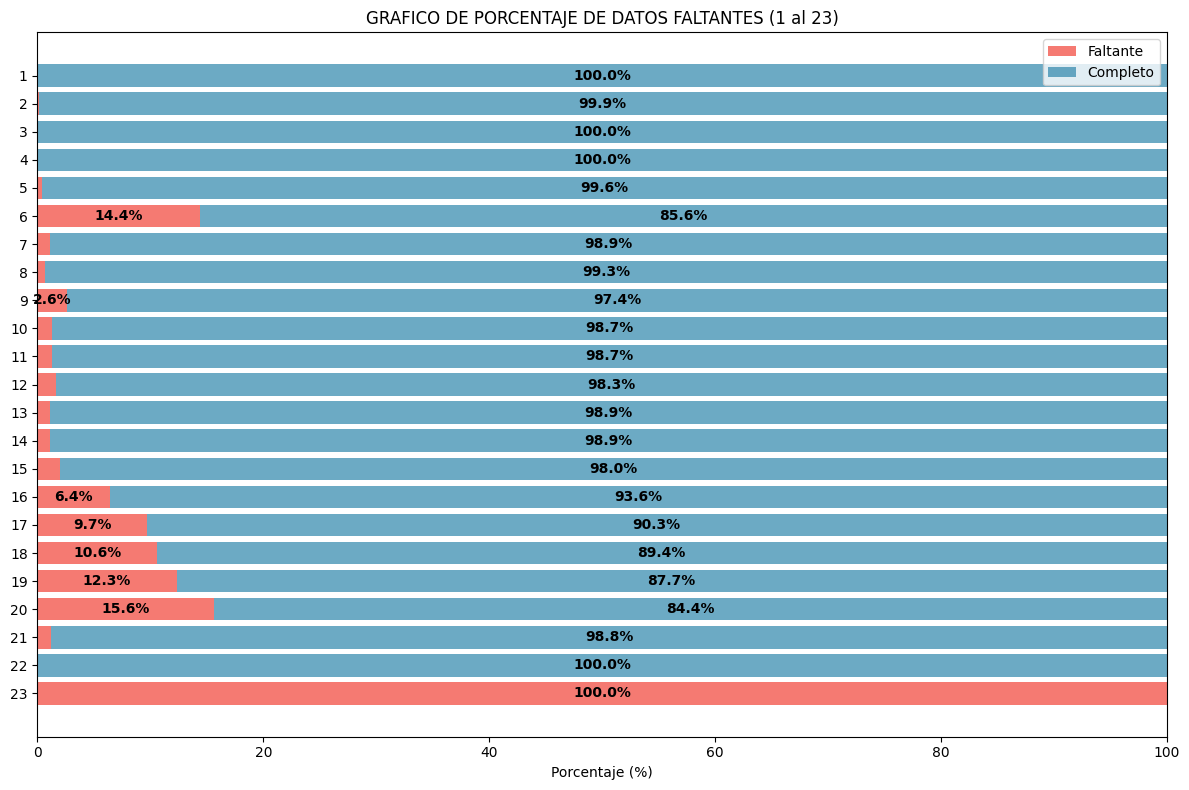

In [206]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Calcular porcentajes
porcentaje_faltantes = (datos_faltantes['TOTAL_FALTANTES'] / len(examen) * 100)
porcentaje_completos = 100 - porcentaje_faltantes

# Crear índices numéricos del 1 al número de columnas
indices = range(1, len(datos_faltantes) + 1)

# Crear gráfico de barras horizontales
plt.barh(indices,
         porcentaje_faltantes,
         color='#F24236', alpha=0.7, label='Faltante')  # rojo claro

plt.barh(indices,
         porcentaje_completos,
         left=porcentaje_faltantes,
         color='#2E86AB', alpha=0.7, label='Completo')  # azul claro

# Etiquetas de porcentaje dentro de las barras
for i, (faltante, completo) in zip(indices, zip(porcentaje_faltantes, porcentaje_completos)):
    if faltante > 2:
        plt.text(faltante / 2, i, f'{faltante:.1f}%',
                 ha='center', va='center', fontweight='bold', color='black')
    if completo > 0:
        plt.text(faltante + completo / 2, i, f'{completo:.1f}%',
                 ha='center', va='center', fontweight='bold', color='black')

# Configurar eje Y: del 1 al N en orden ascendente
plt.yticks(indices, indices)
plt.gca().invert_yaxis()  # 👉 invierte el eje Y para que empiece por 1 abajo y aumente hacia arriba

plt.xlabel('Porcentaje (%)')
plt.title('GRAFICO DE PORCENTAJE DE DATOS FALTANTES (1 al 23)')
plt.legend()
plt.tight_layout()
plt.show()



En general, el conjunto de datos presenta **muy pocos valores faltantes**, lo que indica una buena calidad en las respuestas.

La mayoría de las columnas tienen datos completos, con excepciones leves en algunas variables.  
Por ejemplo:
- “Edad” tiene solo **1 dato faltante**.  
- Variables sobre acceso a tecnología e internet (como “Tiene internet en el celular” o “Tipo de acceso a internet”) presentan entre **4 y 24 valores faltantes**, lo cual es mínimo.  
- Las preguntas abiertas, como las razones de aprobación o reprobación, son las que muestran **mayor cantidad de ausencias** (entre **96 y 142 valores faltantes**), algo común en este tipo de respuestas.  
- La columna “Carrera” carece de **todos los datos (909 faltantes)**, por lo que parece no haber sido respondida por lo cual la mejor opcion es eliminar la columna.  



## **IMPUTACION DE DATOS FALTANTES**
Para la imputacion de datos faltantes se lo hara por columnas ya que en este cuestionario una pregunta depende de la anterior
### **IMPUTACION PARA LA EDAD**
Para la **edad** se imputara por la mediana ya que solo tenemos un unico dato faltante

In [207]:
examen['Escriba su edad en años cumplidos'] = examen['Escriba su edad en años cumplidos'].fillna(examen['Escriba su edad en años cumplidos'].median())



### **IMPUTACION DE: 'En su casa usted dispone de computadora personal, laptop o Tablet?'**
Para imputar la columna 'En su casa usted dispone de computadora personal, laptop o Tablet?' se lo hara mediante la moda ya que este solo tiene valores entre **Si y No** y solo tenemos **4** datos faltantes

In [208]:
examen['En su casa usted dispone de computadora personal, laptop o Tablet?'] = examen['En su casa usted dispone de computadora personal, laptop o Tablet?'].fillna(examen['En su casa usted dispone de computadora personal, laptop o Tablet?'].mode()[0])


### **IMPUTACION DE: 'En su casa usted dispone de:'**
Para imputar la columna **'En su casa usted dispone de:'** primero se visualizara la distribucion de los datos para encontrar el mejor metodo de imputacion

Valores unicos [nan 'Computadora personal' 'Laptop' 'Computadora personal, Laptop'
 'Computadora personal, Laptop, Tablet' 'Laptop, Tablet' 'Tablet'
 'Computadora personal, Tablet']


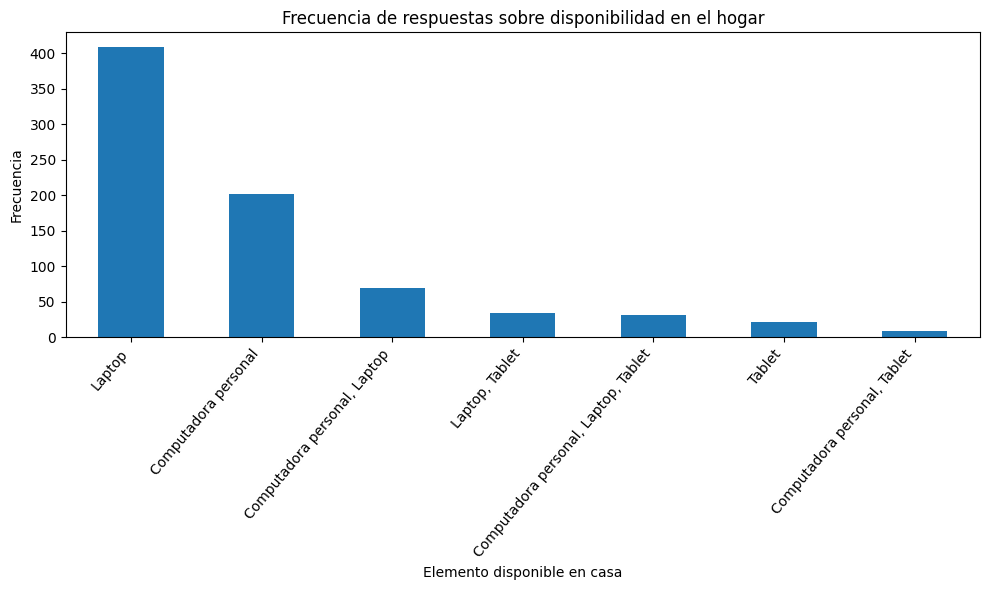

In [209]:
valores_unicos = examen['En su casa usted dispone de:'].unique()
print('Valores unicos',valores_unicos)

# Calcular las frecuencias
frecuencias = examen['En su casa usted dispone de:'].value_counts()
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
frecuencias.plot(kind='bar')

# Personalizar
plt.title('Frecuencia de respuestas sobre disponibilidad en el hogar')
plt.xlabel('Elemento disponible en casa')
plt.ylabel('Frecuencia')
plt.xticks(rotation=50, ha='right')  # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()


Como se puede observar tenemos respuestas compuestas por mas de una palabra, asi que procede a dividir y encontrar la respuesta de una palabra mas frecuente

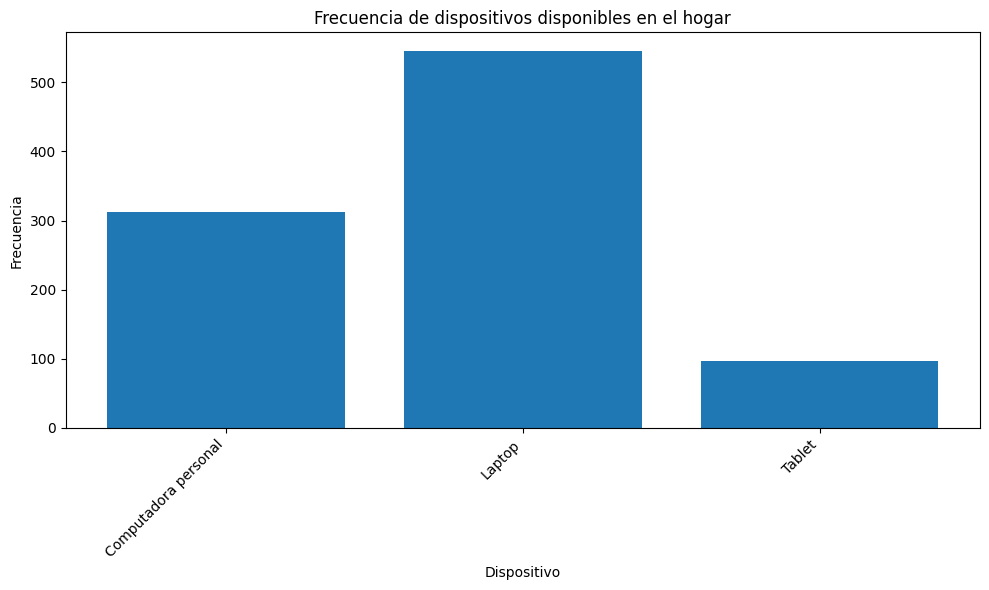

In [210]:
from collections import Counter

# GRAFICO FRECUENCIAS
col = 'En su casa usted dispone de:'

# Dividir por comas para contar correctamente
todas_opciones = [
    item.strip()  # eliminamos espacios
    for sublist in examen[col].dropna().str.split(',')
    for item in sublist
]

# Frecuencia de cada palabra/opción
frecuencias = Counter(todas_opciones)

# Convertimos a dos listas para graficar
etiquetas = list(frecuencias.keys())
valores = list(frecuencias.values())

# Crear gráfico de barras
plt.figure(figsize=(10,6))
plt.bar(etiquetas, valores)

# Personalizar gráfico
plt.title('Frecuencia de dispositivos disponibles en el hogar')
plt.xlabel('Dispositivo')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Esta es la frecuencia individual de la columna **'En su casa usted dispone de:'** como se observa en este caso el valor mas frecuente es Laptop y este sera el valor por el cual se imputaran los datos faltantes


Ademas se imputaraa por la **MODA** en el caso de que la columna:  
 **'En su casa usted dispone de computadora personal, laptop o Tablet?'**

 **'si'**  se imputara por la moda   
 **'No'** se imputara con **ninguno**

In [211]:
from collections import Counter
import pandas as pd

# Funciones
def split_cell(x):
    if pd.isna(x):
        return []
    parts = [p.strip() for p in str(x).split(',') if p and p.strip().lower() not in ('nan', 'none', '')]
    return parts

def respuesta_es_si(x):
    if pd.isna(x):
        return False
    return str(x).strip().lower() in ('sí', 'si', 's', 'yes', 'y')

def imputar_valor(respuesta, lista, modo):
    if not lista:  # lista vacía
        return [modo] if respuesta_es_si(respuesta) else ['ninguno']
    return lista


# Columnas
col_dispositivos = 'En su casa usted dispone de:'
col_pregunta = 'En su casa usted dispone de computadora personal, laptop o Tablet?'

# Separar las celdas por comas y limpiar
examen[col_dispositivos] = examen[col_dispositivos].apply(split_cell)

# Calcular la moda de los valores existentes
todas_opciones = [item for sublist in examen[col_dispositivos] for item in sublist]
modo = Counter(todas_opciones).most_common(1)[0][0]
print("La moda es:", modo)

# Contar cuántas filas vacías hay y cuántas se imputarán con cada tipo
mask_vacias = examen[col_dispositivos].apply(lambda x: len(x) == 0)
mask_si = examen[col_pregunta].apply(respuesta_es_si)

imputar_moda = (mask_vacias & mask_si).sum()
imputar_ninguno = (mask_vacias & ~mask_si).sum()

print(f"Filas vacías totales: {mask_vacias.sum()}")
print(f"Se imputarán con la moda ({modo}): {imputar_moda}")
print(f"Se imputarán con 'ninguno': {imputar_ninguno}")

# Imputar condicionalmente
examen[col_dispositivos] = [
    imputar_valor(resp, val, modo)
    for resp, val in zip(examen[col_pregunta], examen[col_dispositivos])
]

# Unir en formato texto para mantener el formato original
examen[col_dispositivos] = examen[col_dispositivos].apply(lambda x: ', '.join(x))


La moda es: Laptop
Filas vacías totales: 131
Se imputarán con la moda (Laptop): 0
Se imputarán con 'ninguno': 131


Como se observa en los resultados, no se registran casos en los que una persona haya respondido "Sí" en la primera columna y haya dejado la segunda en blanco. Esto tiene sentido, ya que quienes respondieron "No" en la primera pregunta no tenían motivo para completar la segunda.

Valores unicos ['ninguno' 'Computadora personal' 'Laptop' 'Computadora personal, Laptop'
 'Computadora personal, Laptop, Tablet' 'Laptop, Tablet' 'Tablet'
 'Computadora personal, Tablet']


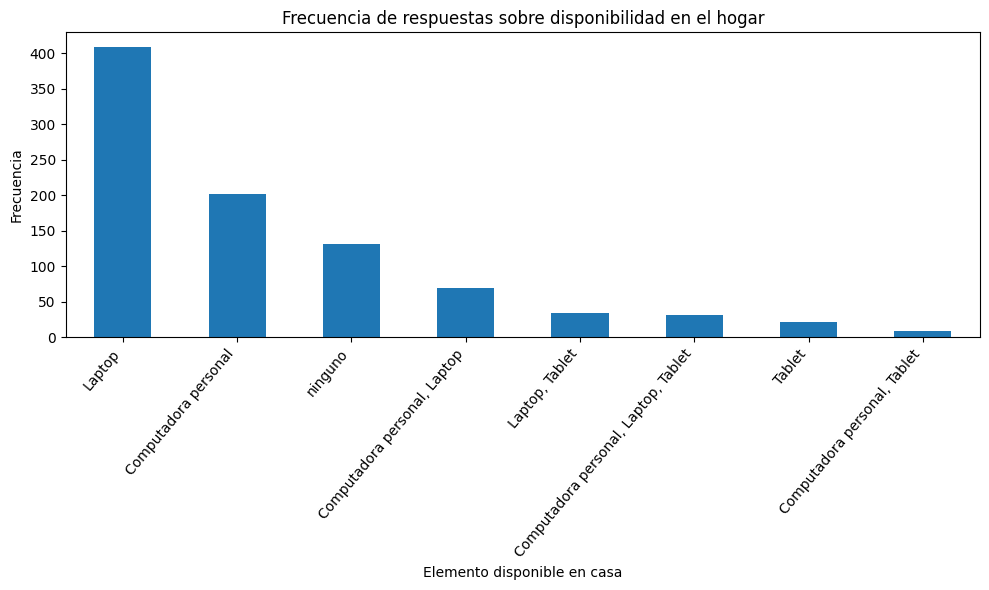

In [212]:
valores_unicos = examen['En su casa usted dispone de:'].unique()
print('Valores unicos',valores_unicos)

# Calcular las frecuencias
frecuencias = examen['En su casa usted dispone de:'].value_counts()
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
frecuencias.plot(kind='bar')

# Personalizar
plt.title('Frecuencia de respuestas sobre disponibilidad en el hogar')
plt.xlabel('Elemento disponible en casa')
plt.ylabel('Frecuencia')
plt.xticks(rotation=50, ha='right')  # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()


### IMPUTACION DE: **'Tiene internet en el celular'** y **'Tiene celular?'**
Se realizará la imputación de valores faltantes en las columnas **`'Tiene internet en el celular'`** y **`'Tiene celular?'`** siguiendo esta lógica:

- Si en la columna**`'Tiene internet en el celular'`** responde que `'Sí'`, se imputa con `'Sí'` en **`'Tiene celular?'`**.
- Si en la columna**`'Tiene internet en el celular'`** responde que `'No'` o está vacío, se imputa `'No'`.

Antes de aplicar la imputación, se contabilizan los casos para tener un control sobre los cambios realizados.

In [213]:

col_internet = 'Tiene internet en el celular'
col_celular = 'Tiene celular?'

# Filtrar las filas donde faltan datos en "Tiene celular?"
faltantes = examen[col_celular].isna() | (examen[col_celular].astype(str).str.strip() == '')

# Condiciones para imputar
cond_si = (examen[col_internet] == 'Sí') & faltantes
cond_no = ((examen[col_internet] == 'No') | (examen[col_internet].isna()) | (examen[col_internet].astype(str).str.strip() == '')) & faltantes

# Contar los casos
num_si = cond_si.sum()
num_no = cond_no.sum()

print(f"Valores a imputar con 'Sí': {num_si}")
print(f"Valores a imputar con 'No': {num_no}")

# Imputar
examen.loc[cond_si, col_celular] = 'Sí'
examen.loc[cond_no, col_celular] = 'No'


Valores a imputar con 'Sí': 1
Valores a imputar con 'No': 5


### IMPUTACION DE: **'Tiene internet en el celular'**

Se imputarán los valores faltantes en **`'Tiene internet en el celular'`** usando la información de **`'Tiene celular?'`**:

- Si **`'Tiene celular?'`** es `'Sí'` y falta información en **`'Tiene internet en el celular'`**, se imputa `'Sí'`.
- Si **`'Tiene celular?'`** es `'No'` y falta información en **`'Tiene internet en el celular'`**, se imputa `'No'`.

Antes de aplicar la imputación, se cuentan los casos que serán actualizados para llevar un control de los cambios.


In [214]:
import pandas as pd

col_internet = 'Tiene internet en el celular'
col_celular = 'Tiene celular?'

# Filtrar filas donde "Tiene internet en el celular" está vacío o NaN
faltantes = examen[col_internet].isna() | (examen[col_internet].astype(str).str.strip() == '')

# Condiciones según "Tiene celular?"
cond_si = (examen[col_celular] == 'Sí') & faltantes
cond_no = (examen[col_celular] == 'No') & faltantes

# Contar cuántos se imputarán
num_si = cond_si.sum()
num_no = cond_no.sum()

print(f"Valores a imputar con 'Sí': {num_si}")
print(f"Valores a imputar con 'No': {num_no}")

# Imputar
examen.loc[cond_si, col_internet] = 'Sí'
examen.loc[cond_no, col_internet] = 'No'


Valores a imputar con 'Sí': 9
Valores a imputar con 'No': 15


### IMPUTACION DE: **Qué tipo de acceso a internet tiene desde su casa?**
para imputar la columna **'Qué tipo de acceso a internet tiene desde su casa?'** primero se visualiza la distribución de esta columna para conocer los valores existentes:

1. **Visualización de frecuencias:**  
   Se calculan las frecuencias de cada tipo de acceso y se muestra un gráfico de barras para facilitar la interpretación.


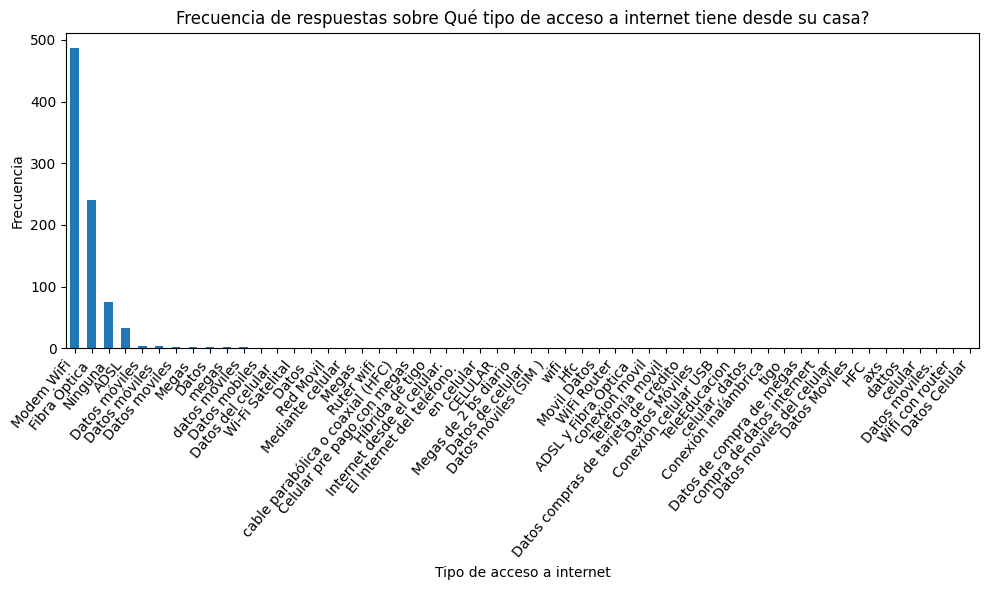

In [215]:
valores_unicos = examen['Qué tipo de acceso a internet tiene desde su casa?'].unique()

# Calcular las frecuencias
frecuencias = examen['Qué tipo de acceso a internet tiene desde su casa?'].value_counts()
# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
frecuencias.plot(kind='bar')

# Personalizar
plt.title('Frecuencia de respuestas sobre Qué tipo de acceso a internet tiene desde su casa?')
plt.xlabel('Tipo de acceso a internet')
plt.ylabel('Frecuencia')
plt.xticks(rotation=50, ha='right')  # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()


2. **Imputación de valores faltantes:**  
   - Si **`'Tiene internet en el celular'`** es `'Sí'` y falta información en esta columna, se imputa `'Datos'`.
   - Si **`'Tiene internet en el celular'`** es `'No'` y falta información, se imputa `'Ninguna'`.

3. **Control de cambios:**  
   Se contabilizan los casos antes de aplicar la imputación para llevar un registro de los datos actualizados.

In [216]:
col_internet = 'Tiene internet en el celular'
col_tipo_internet = 'Qué tipo de acceso a internet tiene desde su casa?'

# Filtrar filas donde "Qué tipo de acceso a internet tiene desde su casa?" está vacío o NaN
faltantes = examen[col_tipo_internet].isna() | (examen[col_tipo_internet].astype(str).str.strip() == '')

# Condiciones según "Tiene internet en el celular"
cond_datos = (examen[col_internet] == 'Sí') & faltantes
cond_ninguna = (examen[col_internet] == 'No') & faltantes

# Contar cuántos se imputarán
num_datos = cond_datos.sum()
num_ninguna = cond_ninguna.sum()

print(f"Valores a imputar con 'Datos': {num_datos}")
print(f"Valores a imputar con 'Ninguna': {num_ninguna}")

# Imputar
examen.loc[cond_datos, col_tipo_internet] = 'Datos'
examen.loc[cond_ninguna, col_tipo_internet] = 'Ninguna'



Valores a imputar con 'Datos': 6
Valores a imputar con 'Ninguna': 4


### **IMPUTACION DE: puntajes y columnas categóricas**

1. **Columna de puntaje:**  
   Para la columna **`'Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?'`**, se calculó la **mediana** y los valores faltantes se imputaron con este valor.  
   Esto asegura que los datos numéricos mantengan una medida central representativa.

2. **Columnas categóricas relacionadas:**  
   Para las columnas **`'Usted preferiría pasar los cursos de manera:'`** y **`'¿Porqué?'`**, los valores faltantes se imputaron con la **moda dentro de cada grupo de puntaje**.  
   De esta manera, la imputación respeta la relación entre el puntaje dado y las preferencias o respuestas correspondientes.

In [217]:
col_puntaje = 'Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?'


# Calcular mediana
mediana = examen[col_puntaje].median()
print("Mediana del puntaje:", mediana)

# Imputar valores faltantes con la mediana
faltantes_puntaje = examen[col_puntaje].isna()
print(f"Valores a imputar con la mediana: {faltantes_puntaje.sum()}")
examen.loc[faltantes_puntaje, col_puntaje] = mediana


Mediana del puntaje: 3.0
Valores a imputar con la mediana: 12


In [218]:
cols_categoricas = ['Usted preferiría pasar los cursos de manera:', '¿Porqué?']

for col in cols_categoricas:
    # Función para imputar con la moda dentro del grupo
    def imputar_por_grupo(grupo):
        moda = grupo.mode()
        if len(moda) == 0:
            return grupo  # Si no hay moda, no cambiar
        moda_val = moda[0]
        return grupo.fillna(moda_val)

    # Aplicar agrupando por el puntaje
    examen[col] = examen.groupby(col_puntaje)[col].transform(imputar_por_grupo)



### **IMPUTACION DE: columnas categóricas por moda**

Se imputarán los valores faltantes en las siguientes columnas utilizando la **moda** (valor más frecuente):

- `'Que plataforma utiliza para sus clases virtuales'`  
- `'En las sesiones on line de clases utiliza'`  
- `'Cuales son los medios de comunicación que utiliza para comunicarse con el docente:'`

**Proceso:**

1. Se calcula la moda de cada columna.  
2. Se contabilizan los valores faltantes que serán imputados.  
3. Se imputan los faltantes con la moda correspondiente, asegurando que los datos reflejen la tendencia más común de cada columna.


In [219]:
cols_moda = [
    'Que plataforma utiliza para sus clases virtuales',
    'En las sesiones on line de clases utiliza',
    'Cuales son los medios de comunicación que utiliza para comunicarse con el docente:'
]
for col in cols_moda:
    # Calcular la moda
    moda = examen[col].mode()
    if len(moda) == 0:
        continue  # Si no hay moda, no imputar
    moda_val = moda[0]

    # Contar cuántos faltantes se van a imputar
    faltantes = examen[col].isna() | (examen[col].astype(str).str.strip() == '')
    print(f"Columna '{col}': valores a imputar = {faltantes.sum()} con moda '{moda_val}'")

    # Imputar con la moda
    examen.loc[faltantes, col] = moda_val

Columna 'Que plataforma utiliza para sus clases virtuales': valores a imputar = 10 con moda 'Classroom'
Columna 'En las sesiones on line de clases utiliza': valores a imputar = 10 con moda 'Meet de Google'
Columna 'Cuales son los medios de comunicación que utiliza para comunicarse con el docente:': valores a imputar = 18 con moda 'Whatsapp, Correo electronico'


### IMPUTACION DE: **materias tomadas y aprobadas**

1. **Visualización de la relación edad-materias:**  
   Se crea un gráfico de cajas (`boxplot`) para observar cómo varía la cantidad de materias tomadas según la edad, lo que ayuda a entender patrones y posibles outliers.

2. **Imputación de materias tomadas:**  
   Los valores faltantes en **`'Cantidad de materias que ha tomado hasta la fecha'`** se imputan usando la **mediana por grupo de edad**. Si no hay suficiente información por edad, se utiliza la mediana global como respaldo.

3. **Imputación de materias aprobadas:**  
   Para **`'Cantidad de materias aprobadas hasta la fecha'`**, se imputan los valores faltantes usando la **mediana por edad**, asegurando que nunca se supere la cantidad de materias tomadas.

4. **Verificación final:**  
   Se comprueba que no queden valores faltantes y se muestran estadísticas descriptivas de ambas columnas para asegurar coherencia y consistencia en los datos.

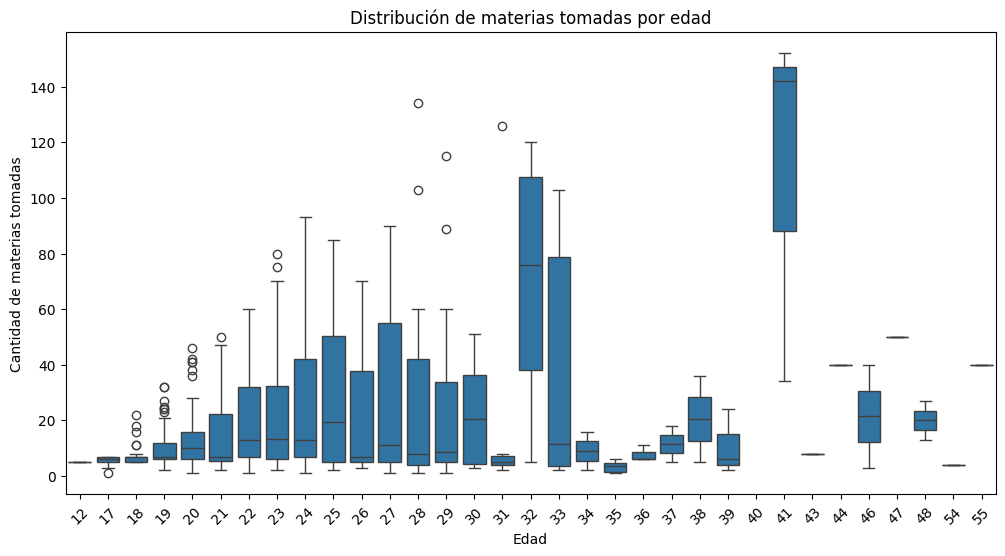

In [220]:


col_edad = 'Escriba su edad en años cumplidos'
col_materias = 'Cantidad de materias que ha tomado hasta la fecha'

plt.figure(figsize=(12, 6))
sns.boxplot(x=col_edad, y=col_materias, data=examen)
plt.xticks(rotation=45)
plt.title('Distribución de materias tomadas por edad')
plt.xlabel('Edad')
plt.ylabel('Cantidad de materias tomadas')
plt.show()

In [221]:
col_edad = 'Escriba su edad en años cumplidos'
col_materias = 'Cantidad de materias que ha tomado hasta la fecha'

# Medianas por edad
medianas_por_edad = examen.groupby(col_edad)[col_materias].median()

# Mediana global como respaldo
mediana_global = examen[col_materias].median()

# Imputar usando map y fillna
examen[col_materias] = examen[col_edad].map(medianas_por_edad)
examen[col_materias].fillna(mediana_global, inplace=True)




C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_8604\1680060131.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  examen[col_materias].fillna(mediana_global, inplace=True)


In [222]:
col_edad = 'Escriba su edad en años cumplidos'
col_tomadas = 'Cantidad de materias que ha tomado hasta la fecha'
col_aprobadas = 'Cantidad de materias aprobadas hasta la fecha'

# --- Medianas por edad ---
medianas_aprobadas_por_edad = examen.groupby(col_edad)[col_aprobadas].median()

# Mediana global como respaldo (ignora pd.NA)
mediana_aprobadas_global = examen[col_aprobadas].median(skipna=True)

# --- Función corregida para imputar ---
def imputar_aprobadas(row):
    val_aprobadas = row[col_aprobadas]
    val_tomadas = row[col_tomadas]

    # Imputar solo si es NA
    if pd.isna(val_aprobadas):
        # Obtener mediana por edad o global
        mediana = medianas_aprobadas_por_edad.get(row[col_edad], mediana_aprobadas_global)
        
        # Si la mediana es NA, usar 0 como respaldo
        if pd.isna(mediana):
            mediana = 0
        
        # Si val_tomadas es NA, usar 0 como respaldo
        if pd.isna(val_tomadas):
            val_tomadas = 0

        # Retornar mínimo entre mediana y materias tomadas, como int
        return int(min(mediana, val_tomadas))
    
    # Mantener valor existente como int
    return int(val_aprobadas)

# --- Aplicar imputación ---
examen[col_aprobadas] = examen.apply(imputar_aprobadas, axis=1)

# --- Verificar ---
print(f"Valores faltantes después de imputar: {examen[col_aprobadas].isna().sum()}")

Valores faltantes después de imputar: 0


In [223]:
col_aprobadas = 'Cantidad de materias aprobadas hasta la fecha'

# Mediana global
mediana_global_aprobadas = examen[col_aprobadas].median()

# Imputar todos los NaN con la mediana global
examen[col_aprobadas] = examen[col_aprobadas].fillna(mediana_global_aprobadas)

# Verificar
print(f"Valores faltantes después de imputar: {examen[col_aprobadas].isna().sum()}")


Valores faltantes después de imputar: 0


### IMPUTACION DE: **'Las razones por la que aprobó sus materias son:'**

Se imputan los valores faltantes en esta columna utilizando la **moda** (valor más frecuente).  
Esto permite completar los datos vacíos con la respuesta más común, manteniendo la tendencia general de las respuestas.  

Se verifica que no queden valores faltantes después de la imputación.


In [224]:
col_razones = 'Las razones por la que aprobó sus materias son:'

# Calcular la moda ignorando NaN
modo_razones = examen[col_razones].mode().iloc[0]

# Imputar los valores faltantes
examen[col_razones].fillna(modo_razones, inplace=True)

# Verificar
print(f"Valores faltantes después de imputar: {examen[col_razones].isna().sum()}")


Valores faltantes después de imputar: 0


C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_8604\3431420257.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  examen[col_razones].fillna(modo_razones, inplace=True)


### IMPUTACION DE:  **'Cantidad de materias reprobadas hasta la fecha'**

Se imputan los valores faltantes en esta columna calculando la diferencia entre **materias tomadas** y **materias aprobadas**:

- Si ambos valores están disponibles, se calcula `reprobadas = tomadas - aprobadas`, asegurando que nunca sea negativo.  
- Si alguno de los datos falta, se asigna **0** como valor mínimo.  
- Los valores existentes se mantienen sin cambios.

Se verifica que no queden valores faltantes después de la imputación.


In [225]:
col_tomadas = 'Cantidad de materias que ha tomado hasta la fecha'
col_aprobadas = 'Cantidad de materias aprobadas hasta la fecha'
col_reprobadas = 'Cantidad de materias reprobadas hasta la fecha.'

# Función para imputar reprobadas
def imputar_reprobadas(row):
    if pd.isna(row[col_reprobadas]):
        if pd.notna(row[col_tomadas]) and pd.notna(row[col_aprobadas]):
            # Asegurar que no sea negativo
            return max(row[col_tomadas] - row[col_aprobadas], 0)
        else:
            # Si faltan datos, imputar 0 como mínimo
            return 0
    return row[col_reprobadas]  # mantener valores existentes

# Aplicar imputación
examen[col_reprobadas] = examen.apply(imputar_reprobadas, axis=1)

# Verificar
print(f"Valores faltantes después de imputar: {examen[col_reprobadas].isna().sum()}")


Valores faltantes después de imputar: 0


### IMPUTACION DE: Imputación de la columna **'Las razones para reprobar fueron:'**

Se completan los valores faltantes utilizando la **moda** (valor más frecuente) de la columna.  
De esta manera, los datos vacíos se imputan con la respuesta más común, manteniendo la tendencia general de las respuestas.  

Se verifica que no queden valores faltantes después de la imputación.


In [226]:
col_reprobar = 'Las razones para reprobar fueron:'

# Calcular la moda ignorando NaN
modo_reprobar = examen[col_reprobar].mode().iloc[0]

# Imputar los valores faltantes
examen[col_reprobar].fillna(modo_reprobar, inplace=True)

# Verificar
print(f"Valores faltantes después de imputar: {examen[col_reprobar].isna().sum()}")


Valores faltantes después de imputar: 0


C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_8604\162390809.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  examen[col_reprobar].fillna(modo_reprobar, inplace=True)


### IMPUTACION DE: **'El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):'**

Se imputan los valores faltantes usando la **mediana** de la columna, lo que permite mantener el nivel central de aprendizaje reportado por los estudiantes.  

Se verifica que no queden valores faltantes después de la imputación.


In [227]:
col_aprendizaje = 'El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):'

# Calcular la mediana ignorando NaN
mediana_aprendizaje = examen[col_aprendizaje].median()

# Imputar valores faltantes
examen[col_aprendizaje].fillna(mediana_aprendizaje, inplace=True)

# Verificar
print(f"Valores faltantes después de imputar: {examen[col_aprendizaje].isna().sum()}")


Valores faltantes después de imputar: 0


C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_8604\1284955821.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  examen[col_aprendizaje].fillna(mediana_aprendizaje, inplace=True)


### REVISION DE VALORES FALTANTES

In [228]:
# ELIMINACION DE LA COLUMNA Carrera
examen = examen.drop('Carrera',axis=1)

#GENERACION DE UNA TABLA DE RESUMEN DE DATOS FALTANTES
datos_faltantes = pd.DataFrame(columns = ['COLUMNA','NAN','VACIOS','TOTAL_FALTANTES'],dtype = str)
for ids,colum in enumerate(examen.columns):
  cant_nan = examen[colum].isna().sum()
  if(examen[colum].dtype=='object'):
    cant_vacios = (examen[colum].astype(str).str.strip() == '').sum()
  else:
    cant_vacios = 0
  datos_faltantes.loc[ids,'COLUMNA'] = colum
  datos_faltantes.loc[ids,'NAN'] = cant_nan
  datos_faltantes.loc[ids,'VACIOS'] = cant_vacios
  datos_faltantes.loc[ids,'TOTAL_FALTANTES'] = cant_nan+cant_vacios


datos_faltantes



,COLUMNA,NAN,VACIOS,TOTAL_FALTANTES
0,Correo electrónico,0,0,0
1,Escriba su edad en años cumplidos,0,0,0
2,Genero al que pertenece,0,0,0
3,Estado Civil,0,0,0
4,En su casa usted dispone de computadora person...,0,0,0
5,En su casa usted dispone de:,0,0,0
6,Qué tipo de acceso a internet tiene desde su c...,0,0,0
7,Tiene celular?,0,0,0
8,Tiene internet en el celular,0,0,0
9,Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qu...,0,0,0


# **4) NORMALIZACION VARIABLES CATEGORICAS**


In [229]:
import pandas as pd
import unicodedata
def normalizar_texto(texto):
    if isinstance(texto, str):

        texto = texto.strip()

        texto = texto.lower()

        texto = ''.join(
            c for c in unicodedata.normalize('NFD', texto)
            if unicodedata.category(c) != 'Mn'
        )
        reemplazos = {
            'concubina': 'concubinato',
            # puedes añadir más reemplazos aquí
            # 'casado': 'matrimonio',
        }
        if texto in reemplazos:
            texto = reemplazos[texto]
        return texto
    return texto

# Función para normalizar y agrupar estados civiles
def normalizar_estado_civil(valor):
    valor = str(valor).strip().lower()  # eliminar espacios y poner en minúsculas
    valor = normalizar_texto(valor)      # tu función existente para limpieza

    # Mapeo para agrupar categorías
    if valor in ['soltero']:
        return 'Soltero'
    elif valor in ['casado', 'conyuge']:
        return 'Casado'
    elif valor in ['divorciado', 'viudo']:
        return 'Separado/Viudo'
    elif valor in ['concubinato', 'conviviente']:
        return 'Unión libre'
    else:
        return 'Otros'





### NORMALIZACION DE: **ESTADO CIVIL**
Se realizó la normalización de la columna Estado Civil para estandarizar los valores, eliminando espacios en blanco, pasando todo a minúsculas, quitando acentos y unificando términos equivalentes. Por ejemplo, se reemplazó "concubina" y "conviviente" por "concubinato" para mantener consistencia en los datos.




In [230]:
# DATOS UNICOS PRESENTES EN ESTADO CIVIL
print(examen['Estado Civil'].unique())

['Casado' 'Soltero' 'Divorciado' 'Concubinato ' 'Viudo' 'Cónyuge'
 'Conviviente' 'Estudiante ' 'Concubina' 'Estudiante']


In [231]:
from tabulate import tabulate

# Contar registros por cada categoría
conteo = examen['Estado Civil'].value_counts()

# Crear lista de filas para la tabla
tabla = []
for i, (categoria, cantidad) in enumerate(conteo.items(), start=1):
    tabla.append([i, categoria, cantidad])

# Imprimir tabla con tabulate
print(tabulate(tabla, headers=["N°", "Estado Civil", "Cantidad"], tablefmt="pretty"))


+----+--------------+----------+
| N° | Estado Civil | Cantidad |
+----+--------------+----------+
| 1  |   Soltero    |   877    |
| 2  |    Casado    |    22    |
| 3  |  Divorciado  |    3     |
| 4  | Concubinato  |    1     |
| 5  |    Viudo     |    1     |
| 6  |   Cónyuge    |    1     |
| 7  | Conviviente  |    1     |
| 8  |  Estudiante  |    1     |
| 9  |  Concubina   |    1     |
| 10 |  Estudiante  |    1     |
+----+--------------+----------+


In [232]:
# Aplicar al DataFrame
examen['Estado Civil'] = examen['Estado Civil'].apply(normalizar_estado_civil)

conteo = examen['Estado Civil'].value_counts()
# Crear lista de filas para la tabla
tabla = []
for i, (categoria, cantidad) in enumerate(conteo.items(), start=1):
    tabla.append([i, categoria, cantidad])
# Verificar resultados
print(tabulate(tabla, headers=["N°", "Estado Civil", "Cantidad"], tablefmt="pretty"))


+----+----------------+----------+
| N° |  Estado Civil  | Cantidad |
+----+----------------+----------+
| 1  |    Soltero     |   877    |
| 2  |     Casado     |    23    |
| 3  | Separado/Viudo |    4     |
| 4  |  Unión libre   |    3     |
| 5  |     Otros      |    2     |
+----+----------------+----------+


Valores únicos en Estado Civil: ['Casado' 'Soltero' 'Separado/Viudo' 'Unión libre' 'Otros']


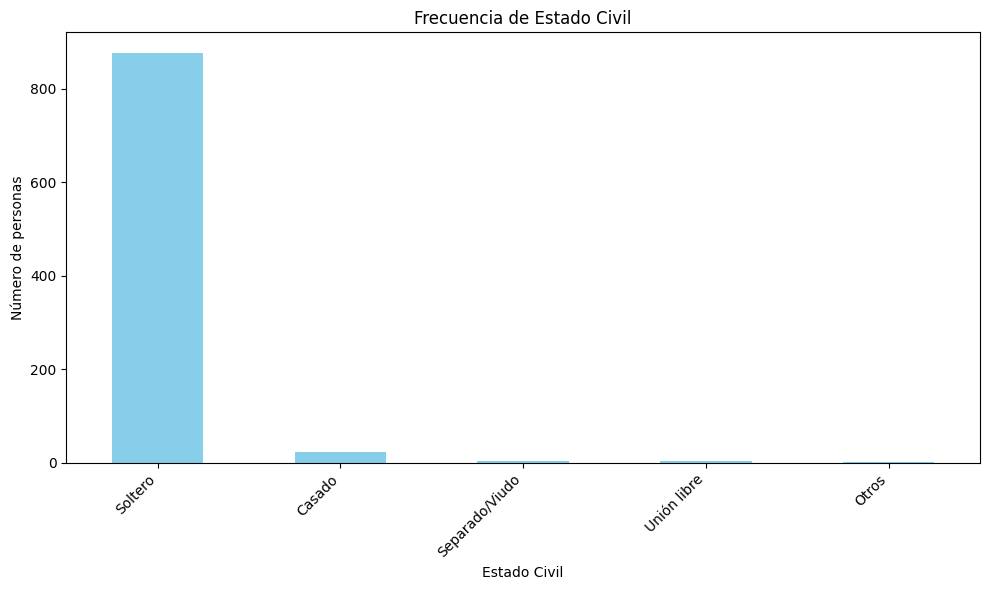

In [233]:
# Mostrar los valores únicos de la columna
valores_unicos = examen['Estado Civil'].unique()
print('Valores únicos en Estado Civil:', valores_unicos)

# Calcular las frecuencias de cada estado civil
frecuencias = examen['Estado Civil'].value_counts()

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
frecuencias.plot(kind='bar', color='skyblue')

# Personalizar el gráfico
plt.title('Frecuencia de Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Número de personas')
plt.xticks(rotation=45, ha='right')  # Rotar etiquetas para mejor legibilidad
plt.tight_layout()
plt.show()


### NORMALIZACION DE: **Qué tipo de acceso a internet tiene desde su casa?**
Se realizó la normalización de la columna para estandarizar los valores de tipo de acceso a Internet, eliminando espacios en blanco, pasando todo a minúsculas y quitando acentos. Además, se unificaron términos equivalentes o variantes ortográficas para mantener consistencia en los datos. Por ejemplo:

Variantes de “Datos móviles” como "Datos Móviles", "Datos del celular", "Mediante celular" se agruparon bajo la categoría "datos moviles".

Variantes de Wi-Fi como "Modem WiFi", "Ruter wifi" y "Wi-Fi Satelital" se agruparon como "wifi".

Se normalizaron otras categorías como "fibra/adsl", "hfc", "tigo" y "teleeducacion".



In [234]:
# DATOS UNICOS PRESENTES EN ESTADO CIVIL
print(examen['Qué tipo de acceso a internet tiene desde su casa?'].unique())
print('cantidad de tipos de acceso unicos:', len(examen['Qué tipo de acceso a internet tiene desde su casa?'].unique()))



['Ninguna' 'Datos moviles' 'Modem WiFi' 'Datos móviles' 'Fibra Óptica'
 'ADSL' 'Megas' 'Híbrida de tigo' 'Datos del celular ' 'Datos mobiles'
 'Wi-Fi Satelital' 'Datos' 'megas' 'Red Movil' 'Datos ' 'Megas '
 'Mediante celular' 'Datos móviles ' 'Ruter wifi'
 'cable parabólica o coaxial (HFC)' 'Celular pre pago con megas'
 'Internet desde el celular.' 'El Internet del teléfono. ' 'CELULAR'
 'en celular' 'Megas de 2 bs diario' 'datos moviles' 'Datos de celular '
 'Datos móviles (SIM )' 'wifi' 'Hfc' 'Movil Datos' 'WiFi Router'
 'ADSL y Fibra Óptica' 'conexion movil' 'Telefonía movil'
 'Datos compras de tarjeta de crédito' 'Datos Móviles '
 'Conexión celular USB' 'TeleEducacion' 'celular, datos'
 'Conexión inalámbrica' 'tigo' 'Datos de compra de megas'
 'compra de datos internert' 'Datos moviles del celular' 'Datos Moviles'
 'HFC' 'axs' 'dattos' 'celular' 'Datos moviles.' 'Wifi con router'
 'Datos Celular']
cantidad de tipos de acceso unicos: 54


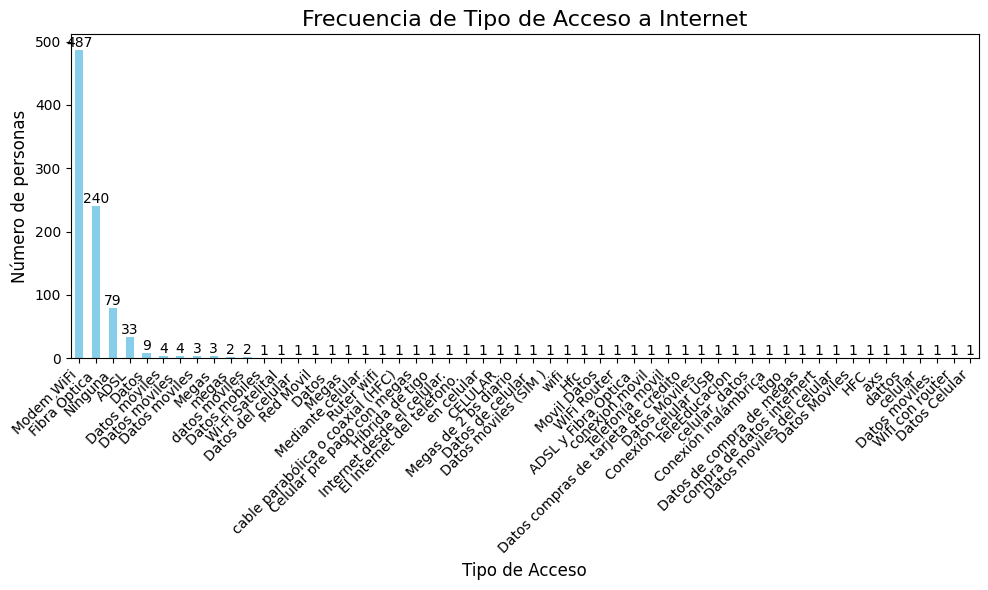

In [235]:
frecuencias = examen['Qué tipo de acceso a internet tiene desde su casa?'].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
ax = frecuencias.plot(kind='bar', color='skyblue')

# Personalizar gráfico
plt.title('Frecuencia de Tipo de Acceso a Internet', fontsize=16)
plt.xlabel('Tipo de Acceso', fontsize=12)
plt.ylabel('Número de personas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Mostrar número encima de cada barra
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()


In [236]:
import pandas as pd
import unicodedata

# Diccionario con listas más completas
internet_map = {
    'ninguna': ['ninguna'],
    'datos moviles': [
        'datos moviles', 'datos móviles', 'datos mobiles', 'datos',
        'mediante celular', 'celular', 'datos del celular', 'datos de celular',
        'datos móviles (sim )', 'datos compras de tarjeta de crédito',
        'datos de compra de megas', 'compra de datos internert', 'megas',
        'datos moviles del celular', 'datos móviles ', 'datos moviles.',
        'celular, datos', 'movil datos', 'conexion movil', 'telefonía movil',
        'en celular', 'conexion celular usb', 'el internet del telefono.',
        'megas de 2 bs diario', 'datos de celular', 'datos movil','dattos','datos celular',
        'celular pre pago con megas', 'internet desde el celular.','tigo', 'hibrida de tigo', 'red movil'
    ],
    'wifi': [
        'modem wifi', 'ruter wifi', 'wifi', 'wifi router',
        'conexión inalámbrica', 'wifi satelital', 'wifi con router',
        'wi-fi satelital','fibra optica', 'adsl', 'adsl y fibra optica', 'fibra optica/adsl','fibra optica', 'adsl', 'adsl y fibra optica', 'fibra optica/adsl',
        'hfc', 'cable parabolica o coaxial (hfc)', 'axs', 'HFC','teleeducacion'
    ]
}


# Función para limpiar texto
def limpiar_texto(texto):
    if isinstance(texto, str):
        texto = texto.strip().lower()
        texto = ''.join(
            c for c in unicodedata.normalize('NFD', texto)
            if unicodedata.category(c) != 'Mn'
        )
        return texto
    return texto

# Crear diccionario invertido para búsquedas rápidas
internet_map_invertido = {}
for categoria, variantes in internet_map.items():
    for v in variantes:
        internet_map_invertido[limpiar_texto(v)] = categoria

# Función de normalización
def normalizar_internet(texto):
    texto = limpiar_texto(texto)
    return internet_map_invertido.get(texto, texto)  # devuelve categoría o deja el original

# Aplicar al DataFrame
examen['Qué tipo de acceso a internet tiene desde su casa?'] = examen['Qué tipo de acceso a internet tiene desde su casa?'].apply(normalizar_internet)




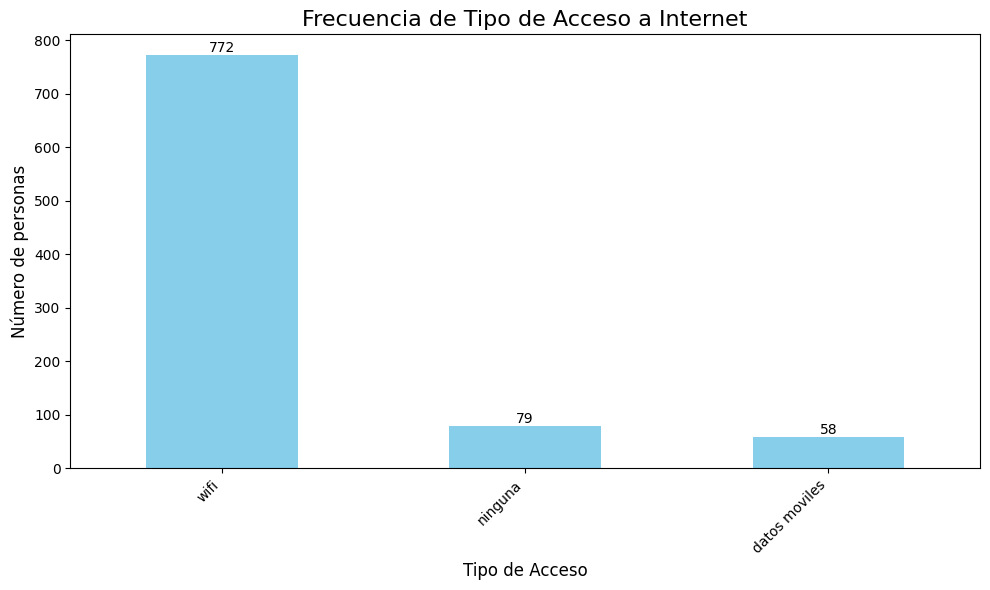

In [237]:
frecuencias = examen['Qué tipo de acceso a internet tiene desde su casa?'].value_counts()

# Crear gráfico de barras
plt.figure(figsize=(10, 6))
ax = frecuencias.plot(kind='bar', color='skyblue')

# Personalizar gráfico
plt.title('Frecuencia de Tipo de Acceso a Internet', fontsize=16)
plt.xlabel('Tipo de Acceso', fontsize=12)
plt.ylabel('Número de personas', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Mostrar número encima de cada barra
for p in ax.patches:
    ax.annotate(str(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.show()


In [238]:
# DATOS UNICOS PRESENTES EN ESTADO CIVIL
print(examen['Qué tipo de acceso a internet tiene desde su casa?'].unique())


['ninguna' 'datos moviles' 'wifi']


# **5)TRATAMIENTO DE VALORES DUPLICADOS**
En esta sección, para la identificación de valores duplicados, se utilizará la columna **Correo electrónico**, ya que actúa como el identificador único de cada registro en el dataset.


In [239]:
import pandas as pd
from tabulate import tabulate

# Cantidad total de registros
total_filas = len(examen)

# Cantidad de correos únicos
correos_unicos = examen['Correo electrónico'].nunique()

# Cantidad de correos duplicados
correos_duplicados = total_filas - correos_unicos

# Crear tabla resumida
tabla_resumen = [
    ["Total de registros", total_filas],
    ["Correos únicos", correos_unicos],
    ["Registros duplicados", correos_duplicados],
    ["% de duplicados", f"{(correos_duplicados/total_filas)*100:.2f}%"]
]

print(tabulate(tabla_resumen, headers=["Concepto", "Cantidad"], tablefmt="pretty"))

# Mostrar filas duplicadas (opcional)
duplicados = examen[examen.duplicated(subset=['Correo electrónico'], keep=False)]
if not duplicados.empty:
    print("\nFilas duplicadas según correo electrónico:")
    print(tabulate(duplicados, headers="keys", tablefmt="pretty", showindex=True))
else:
    print("\nNo hay registros duplicados según correo electrónico.")



+----------------------+----------+
|       Concepto       | Cantidad |
+----------------------+----------+
|  Total de registros  |   909    |
|    Correos únicos    |   909    |
| Registros duplicados |    0     |
|   % de duplicados    |  0.00%   |
+----------------------+----------+

No hay registros duplicados según correo electrónico.


# **6) CREACION DE NUEVAS VARIABLES**


In [240]:
import pandas as pd
from tabulate import tabulate

# Información de dimensiones
filas, columnas = examen.shape

# Crear tabla con los datos
tabla = [["Filas", filas],
         ["Columnas", columnas]]

# Mostrar tabla centrada y tabulada
print(tabulate(tabla, headers=["Dimensión", "Cantidad"], tablefmt="pretty", stralign="center"))


+-----------+----------+
| Dimensión | Cantidad |
+-----------+----------+
|   Filas   |   909    |
| Columnas  |    22    |
+-----------+----------+


In [241]:
from tabulate import tabulate

# Crear lista con columnas y sus tipos
columnas_info = [[col, str(examen[col].dtype)] for col in examen.columns]

# Mostrar la tabla centrada y tabulada
print(tabulate(columnas_info, headers=["Nombre de columna", "Tipo de dato"], tablefmt="pretty", stralign="center"))


+---------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+
|                                                                    Nombre de columna                                                                    | Tipo de dato |
+---------------------------------------------------------------------------------------------------------------------------------------------------------+--------------+
|                                                                   Correo electrónico                                                                    |    object    |
|                                                            Escriba su edad en años cumplidos                                                            |    Int64     |
|                                                                 Genero al que pertenece                                                        

In [242]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# -------------------------------------------------
# 1. Columnas a excluir
# -------------------------------------------------
excluir = ['Correo electrónico', 'Dirección de correo electrónico']

# Crear copia sin las columnas excluidas
df = examen.drop(columns=excluir)

# -------------------------------------------------
# 2. Detectar columnas categóricas
# -------------------------------------------------
cat_cols = df.select_dtypes(include=['object']).columns

# Contar categorías por columna
categorias_por_columna = df[cat_cols].nunique()

# Crear un diccionario: número → columna
mapa_numeros = {i+1: col for i, col in enumerate(categorias_por_columna.index)}

# Crear serie con índices numéricos
categorias_numeradas = categorias_por_columna.copy()
categorias_numeradas.index = list(mapa_numeros.keys())



# -------------------------------------------------
# 4. Mostrar equivalencias con tabla ordenada
# -------------------------------------------------
tabla = []

for numero, columna in mapa_numeros.items():
    cantidad = categorias_por_columna[columna]
    tabla.append([numero, columna, cantidad])

print("\n===============================")
print("Tabla de equivalencias")
print("===============================")
print(tabulate(tabla, headers=["N°", "Columna", "Categorías únicas"], tablefmt="pretty"))



Tabla de equivalencias
+----+------------------------------------------------------------------------------------+-------------------+
| N° |                                      Columna                                       | Categorías únicas |
+----+------------------------------------------------------------------------------------+-------------------+
| 1  |                              Genero al que pertenece                               |         2         |
| 2  |                                    Estado Civil                                    |         5         |
| 3  |         En su casa usted dispone de computadora personal, laptop o Tablet?         |         2         |
| 4  |                            En su casa usted dispone de:                            |         8         |
| 5  |                 Qué tipo de acceso a internet tiene desde su casa?                 |         3         |
| 6  |                                   Tiene celular?                         


En esta seccion no se han creado nuevas variables, ya que las **22 columnas existentes** contienen **suficiente información** para realizar el análisis descriptivo, exploratorio y posterior modelado.  

Agregar variables adicionales podría **aumentar la densidad del dataset**, lo que complicaría la **codificación de valores categóricos a numéricos** y dificultaría el manejo del dataset.  

Por ello, se mantiene el conjunto de variables original, asegurando un análisis **claro, eficiente y manejable**.

In [243]:
examen.to_csv("data/analisis/examen_respuestas_prepro_.csv", index=False, encoding="utf-8")
# para el analisis de datos


# **7) TRATAMIENTO DE OUTLIERS**


In [244]:
resumen = examen.describe(include='all')
# Transpuesta
resumen_T = resumen.T
resumen_T['Tipo_dato'] = resumen.dtypes
resumen_T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,Tipo_dato
Correo electrónico,909,909,lchural@fcpn.edu.bo,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Escriba su edad en años cumplidos,909.0,<NA>,<NA>,<NA>,22.89549,5.010679,12.0,20.0,22.0,25.0,55.0,Float64
Genero al que pertenece,909,2,Masculino,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Estado Civil,909,5,Soltero,877,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
"En su casa usted dispone de computadora personal, laptop o Tablet?",909,2,Sí,778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
En su casa usted dispone de:,909,8,Laptop,409,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Qué tipo de acceso a internet tiene desde su casa?,909,3,wifi,772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Tiene celular?,909,2,Sí,894,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Tiene internet en el celular,909,2,Sí,856,NaN,NaN,NaN,NaN,NaN,NaN,NaN,object
Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?,909.0,<NA>,<NA>,<NA>,2.961496,1.005301,1.0,2.0,3.0,4.0,5.0,Float64


## **DISTRIBUCION DE LOS DATOS**

Variables numéricas a graficar:
1: Cantidad de materias aprobadas hasta la fecha
2: Cantidad de materias reprobadas hasta la fecha.

1: Cantidad de materias aprobadas hasta la fecha
  Valores faltantes: 0
  Min: -1, Max: 50, Media: 12.09, Mediana: 6.0
  Q1: 0.0, Q3: 19.0, IQR: 19.0
  Outliers: 35

2: Cantidad de materias reprobadas hasta la fecha.
  Valores faltantes: 0
  Min: 0.0, Max: 60.0, Media: 5.46, Mediana: 3.0
  Q1: 0.0, Q3: 7.0, IQR: 7.0
  Outliers: 76


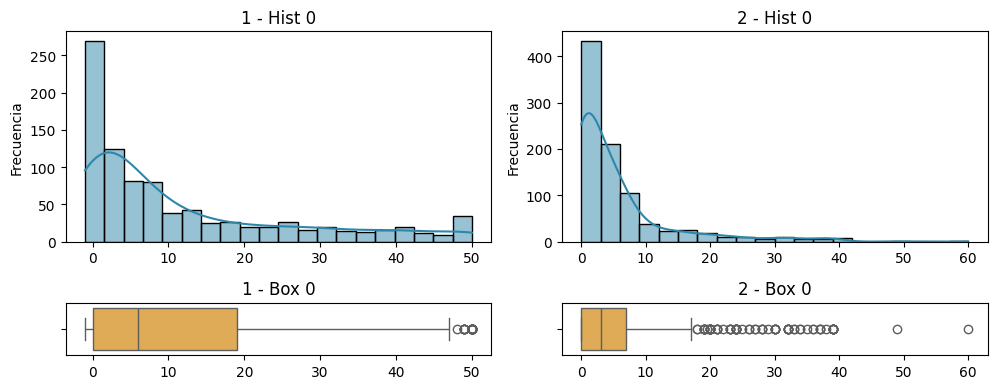

In [245]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar variables numéricas
num_cols = [c for c in examen.columns if examen[c].dtype in ['int64','float64']]

# Imprimir mini-report con números
print("Variables numéricas a graficar:")
for i, col in enumerate(num_cols, start=1):
    print(f"{i}: {col}")

def plot_num_with_box(data, cols):
    n = len(cols)
    cols_per_row = 4
    n_rows = math.ceil(n / cols_per_row)

    fig, axes = plt.subplots(2 * n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows),
                             gridspec_kw={'height_ratios': [4, 1] * n_rows})

    if n_rows == 1:
        axes = np.array(axes)
    if axes.ndim == 1:
        axes = axes.reshape(2*n_rows, cols_per_row)

    for idx, col in enumerate(cols):
        row_idx = (idx // cols_per_row) * 2
        col_idx = idx % cols_per_row
        graf_num = idx + 1

        col_data = data[col].dropna()
        n_missing = data[col].isna().sum()

        # Estadísticas
        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        min_val = col_data.min()
        max_val = col_data.max()
        median = col_data.median()
        mean = col_data.mean()
        # Outliers
        outliers = col_data[(col_data < q1 - 1.5*iqr) | (col_data > q3 + 1.5*iqr)]
        n_outliers = len(outliers)

        # Print resumen
        print(f"\n{graf_num}: {col}")
        print(f"  Valores faltantes: {n_missing}")
        print(f"  Min: {min_val}, Max: {max_val}, Media: {mean:.2f}, Mediana: {median}")
        print(f"  Q1: {q1}, Q3: {q3}, IQR: {iqr}")
        print(f"  Outliers: {n_outliers}")

        # Títulos con número y cantidad de faltantes
        title_hist = f'{graf_num} - Hist {n_missing}'
        title_box = f'{graf_num} - Box {n_missing}'

        # Histograma
        sns.histplot(data=data, x=col, ax=axes[row_idx, col_idx], bins=20, kde=True, color='#2E86AB')
        axes[row_idx, col_idx].set_title(title_hist)
        axes[row_idx, col_idx].set_xlabel("")
        axes[row_idx, col_idx].set_ylabel("Frecuencia")

        # Boxplot
        if col_data.nunique() >= 2:
            color = '#F08080' if n_missing > 0 else '#F5B041'
            sns.boxplot(data=data, x=col, ax=axes[row_idx+1, col_idx], color=color)
        else:
            axes[row_idx+1, col_idx].text(0.5, 0.5, 'No hay datos suficientes', ha='center', va='center')
        axes[row_idx+1, col_idx].set_title(title_box)
        axes[row_idx+1, col_idx].set_xlabel("")
        axes[row_idx+1, col_idx].set_ylabel("")

    # Ocultar ejes vacíos
    for j in range(n, n_rows*cols_per_row):
        for i in [0,1]:
            axes[(j//cols_per_row)*2 + i, j%cols_per_row].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_num_with_box(examen, num_cols)


## **WINZORIZACION**

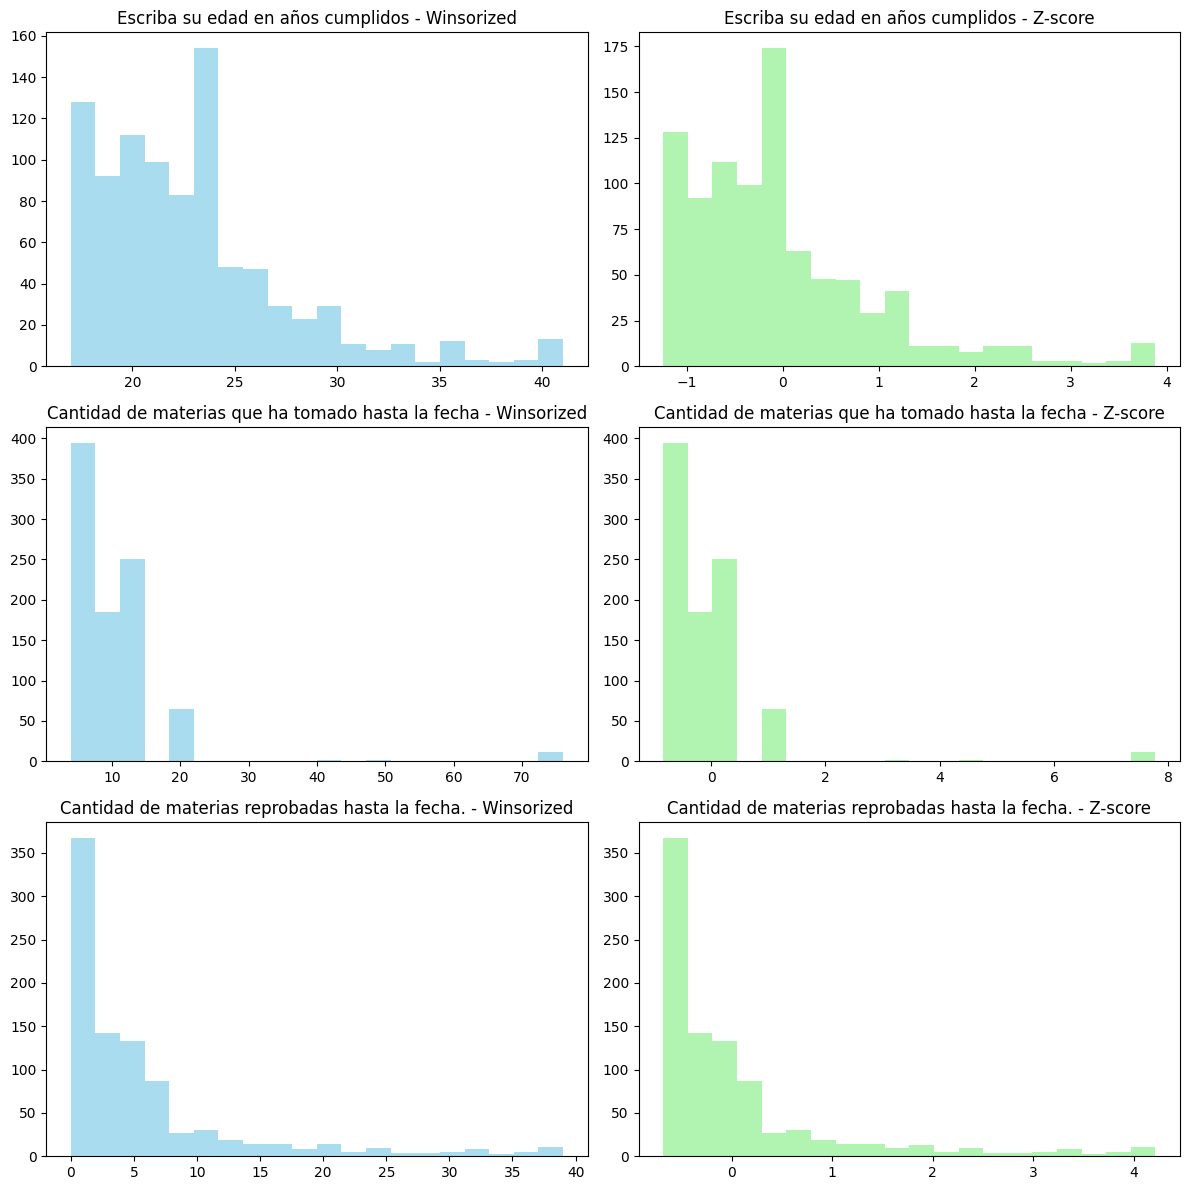

In [246]:
from sklearn.preprocessing import StandardScaler
from scipy.stats.mstats import winsorize
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Columnas numéricas a procesar
# -----------------------------
num_cols = [
    'Escriba su edad en años cumplidos',
    'Cantidad de materias que ha tomado hasta la fecha',
    'Cantidad de materias reprobadas hasta la fecha.'
]

# -----------------------------
# Winsorización (solo numéricas)
# -----------------------------
df_winsorized = examen.copy()

for col in num_cols:
    # Convertir a float y reemplazar pd.NA por np.nan
    data = df_winsorized[col].astype(float)
    df_winsorized[col] = winsorize(data, limits=[0.01, 0.01])

# Renombrar columnas con sufijo "_wins"
df_winsorized = df_winsorized.rename(
    columns={col: col+"_wins" for col in num_cols}
)

# -----------------------------
# Estandarización Z-score (sobre numéricas winsorizadas)
# -----------------------------
scaler_std = StandardScaler()
df_standardized = df_winsorized.copy()
df_standardized[[c+"_wins" for c in num_cols]] = scaler_std.fit_transform(
    df_winsorized[[c+"_wins" for c in num_cols]]
)

# Renombrar columnas con sufijo "_std"
df_standardized = df_standardized.rename(
    columns={col+"_wins": col+"_std" for col in num_cols}
)

# -----------------------------
# Graficar comparaciones
# -----------------------------
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4*len(num_cols)))

for i, col in enumerate(num_cols):
    # Winsorizada
    axes[i,0].hist(df_winsorized[col+'_wins'], bins=20, color='skyblue', alpha=0.7)
    axes[i,0].set_title(f'{col} - Winsorized')

    # Estandarización Z-score
    axes[i,1].hist(df_standardized[col+'_std'], bins=20, color='lightgreen', alpha=0.7)
    axes[i,1].set_title(f'{col} - Z-score')

plt.tight_layout()
plt.show()


# **8) NORMALIZAR Y ESTANDARIZAR***=

Variables numéricas a graficar:
1: Escriba su edad en años cumplidos_wins
2: Cantidad de materias que ha tomado hasta la fecha_wins
3: Cantidad de materias aprobadas hasta la fecha
4: Cantidad de materias reprobadas hasta la fecha._wins

1: Escriba su edad en años cumplidos_wins
  Valores faltantes: 0
  Min: 17.0, Max: 41.0, Media: 22.83, Mediana: 22.0
  Q1: 20.0, Q3: 25.0, IQR: 5.0
  Outliers: 46

2: Cantidad de materias que ha tomado hasta la fecha_wins
  Valores faltantes: 0
  Min: 4.0, Max: 76.0, Media: 11.01, Mediana: 10.0
  Q1: 7.0, Q3: 13.0, IQR: 6.0
  Outliers: 14

3: Cantidad de materias aprobadas hasta la fecha
  Valores faltantes: 0
  Min: -1, Max: 50, Media: 12.09, Mediana: 6.0
  Q1: 0.0, Q3: 19.0, IQR: 19.0
  Outliers: 35

4: Cantidad de materias reprobadas hasta la fecha._wins
  Valores faltantes: 0
  Min: 0.0, Max: 39.0, Media: 5.43, Mediana: 3.0
  Q1: 0.0, Q3: 7.0, IQR: 7.0
  Outliers: 76


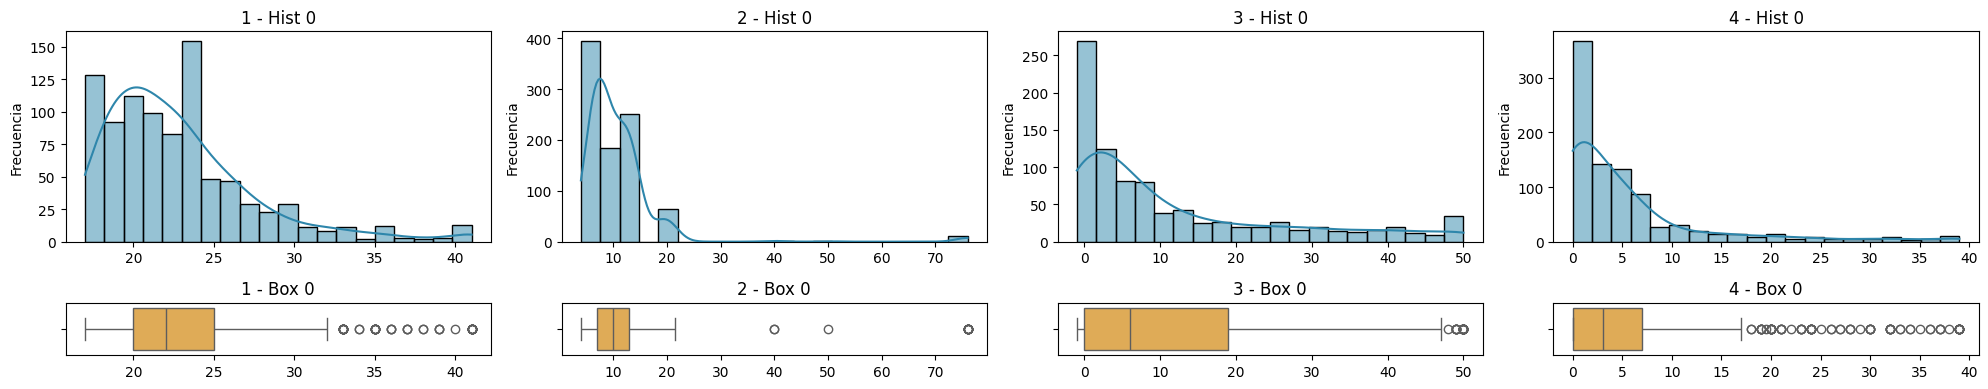


Variables numéricas a graficar:
1: Escriba su edad en años cumplidos_std
2: Cantidad de materias que ha tomado hasta la fecha_std
3: Cantidad de materias aprobadas hasta la fecha
4: Cantidad de materias reprobadas hasta la fecha._std

1: Escriba su edad en años cumplidos_std
  Valores faltantes: 0
  Min: -1.2465309306256187, Max: 3.8825371158716475, Media: 0.00, Mediana: -0.17797508760535488
  Q1: -0.6053974248134604, Q3: 0.46315841820680337, IQR: 1.0685558430202637
  Outliers: 46

2: Cantidad de materias que ha tomado hasta la fecha_std
  Valores faltantes: 0
  Min: -0.8380388044888473, Max: 7.773668477060232, Media: 0.00, Mediana: -0.12039653102642407
  Q1: -0.4792176677576357, Q3: 0.23842460570478755, IQR: 0.7176422734624233
  Outliers: 14

3: Cantidad de materias aprobadas hasta la fecha
  Valores faltantes: 0
  Min: -1, Max: 50, Media: 12.09, Mediana: 6.0
  Q1: 0.0, Q3: 19.0, IQR: 19.0
  Outliers: 35

4: Cantidad de materias reprobadas hasta la fecha._std
  Valores faltantes: 0
 

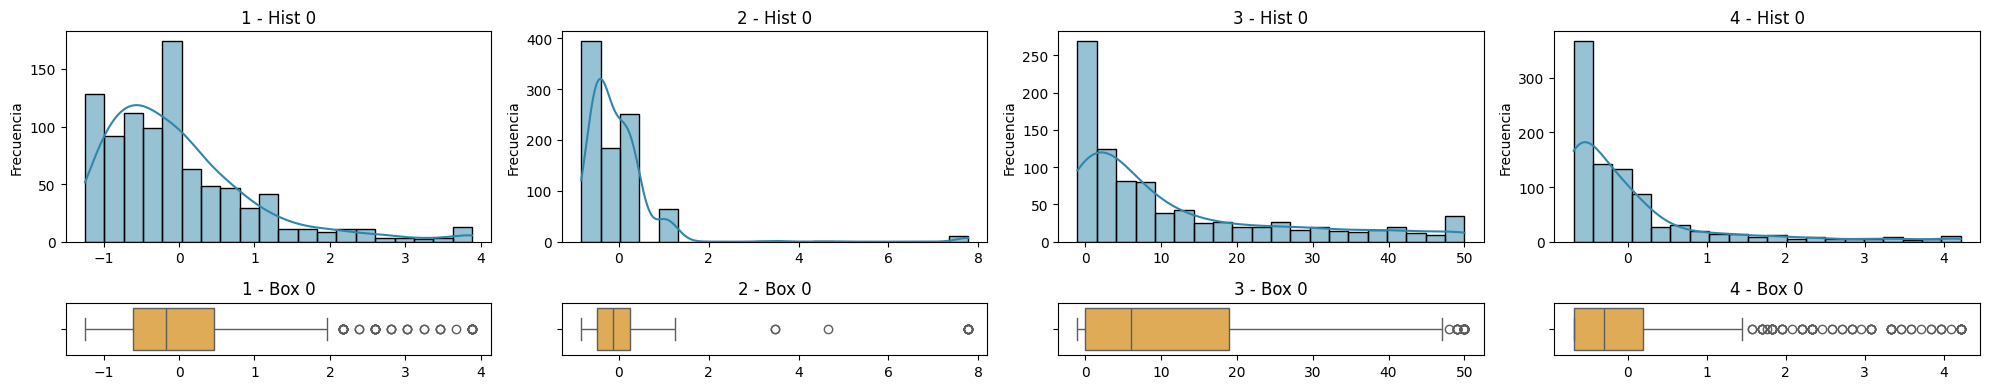

In [247]:
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de distribuciones: solo winsorizada y estandarizada
distribuciones = [df_winsorized, df_standardized]

for k in distribuciones:

    # Seleccionar variables numéricas
    num_cols = [c for c in k.columns if k[c].dtype in ['int64', 'float64']]

    # Imprimir mini-report con números
    print("Variables numéricas a graficar:")
    for i, col in enumerate(num_cols, start=1):
        print(f"{i}: {col}")

    def plot_num_with_box(data, cols):
        n = len(cols)
        cols_per_row = 4
        n_rows = math.ceil(n / cols_per_row)

        fig, axes = plt.subplots(2 * n_rows, cols_per_row, figsize=(5*cols_per_row, 4*n_rows),
                                gridspec_kw={'height_ratios': [4, 1] * n_rows})

        if n_rows == 1:
            axes = np.array(axes)
        if axes.ndim == 1:
            axes = axes.reshape(2*n_rows, cols_per_row)

        for idx, col in enumerate(cols):
            row_idx = (idx // cols_per_row) * 2
            col_idx = idx % cols_per_row
            graf_num = idx + 1

            col_data = data[col].dropna()
            n_missing = data[col].isna().sum()

            # Estadísticas
            q1 = col_data.quantile(0.25)
            q3 = col_data.quantile(0.75)
            iqr = q3 - q1
            min_val = col_data.min()
            max_val = col_data.max()
            median = col_data.median()
            mean = col_data.mean()
            # Outliers
            outliers = col_data[(col_data < q1 - 1.5*iqr) | (col_data > q3 + 1.5*iqr)]
            n_outliers = len(outliers)

            # Print resumen
            print(f"\n{graf_num}: {col}")
            print(f"  Valores faltantes: {n_missing}")
            print(f"  Min: {min_val}, Max: {max_val}, Media: {mean:.2f}, Mediana: {median}")
            print(f"  Q1: {q1}, Q3: {q3}, IQR: {iqr}")
            print(f"  Outliers: {n_outliers}")

            # Títulos con número y cantidad de faltantes
            title_hist = f'{graf_num} - Hist {n_missing}'
            title_box = f'{graf_num} - Box {n_missing}'

            # Histograma
            sns.histplot(data=data, x=col, ax=axes[row_idx, col_idx], bins=20, kde=True, color='#2E86AB')
            axes[row_idx, col_idx].set_title(title_hist)
            axes[row_idx, col_idx].set_xlabel("")
            axes[row_idx, col_idx].set_ylabel("Frecuencia")

            # Boxplot
            if col_data.nunique() >= 2:
                color = '#F08080' if n_missing > 0 else '#F5B041'
                sns.boxplot(data=data, x=col, ax=axes[row_idx+1, col_idx], color=color)
            else:
                axes[row_idx+1, col_idx].text(0.5, 0.5, 'No hay datos suficientes', ha='center', va='center')
            axes[row_idx+1, col_idx].set_title(title_box)
            axes[row_idx+1, col_idx].set_xlabel("")
            axes[row_idx+1, col_idx].set_ylabel("")

        # Ocultar ejes vacíos
        for j in range(n, n_rows*cols_per_row):
            for i in [0,1]:
                axes[(j//cols_per_row)*2 + i, j%cols_per_row].set_visible(False)

        plt.tight_layout()
        plt.show()

    plot_num_with_box(k, num_cols)
    print("="*120)
    print("="*120 + "\n")


# **9) REDUCCION DE DIMENSIONALIDAD**

In [248]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Selección de variables categóricas (excluyendo emails)
categoricas = examen.select_dtypes(include=['object']).columns.tolist()
excluir = ['Correo electrónico','Dirección de correo electrónico']
categoricas = [c for c in categoricas if c not in excluir]

# Función Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2/n
    r,k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Matriz de relaciones
matriz_cramers = pd.DataFrame(index=categoricas, columns=categoricas)

for c1 in categoricas:
    for c2 in categoricas:
        matriz_cramers.loc[c1,c2] = cramers_v(examen[c1], examen[c2])

matriz_cramers = matriz_cramers.astype(float)
#print(matriz_cramers)


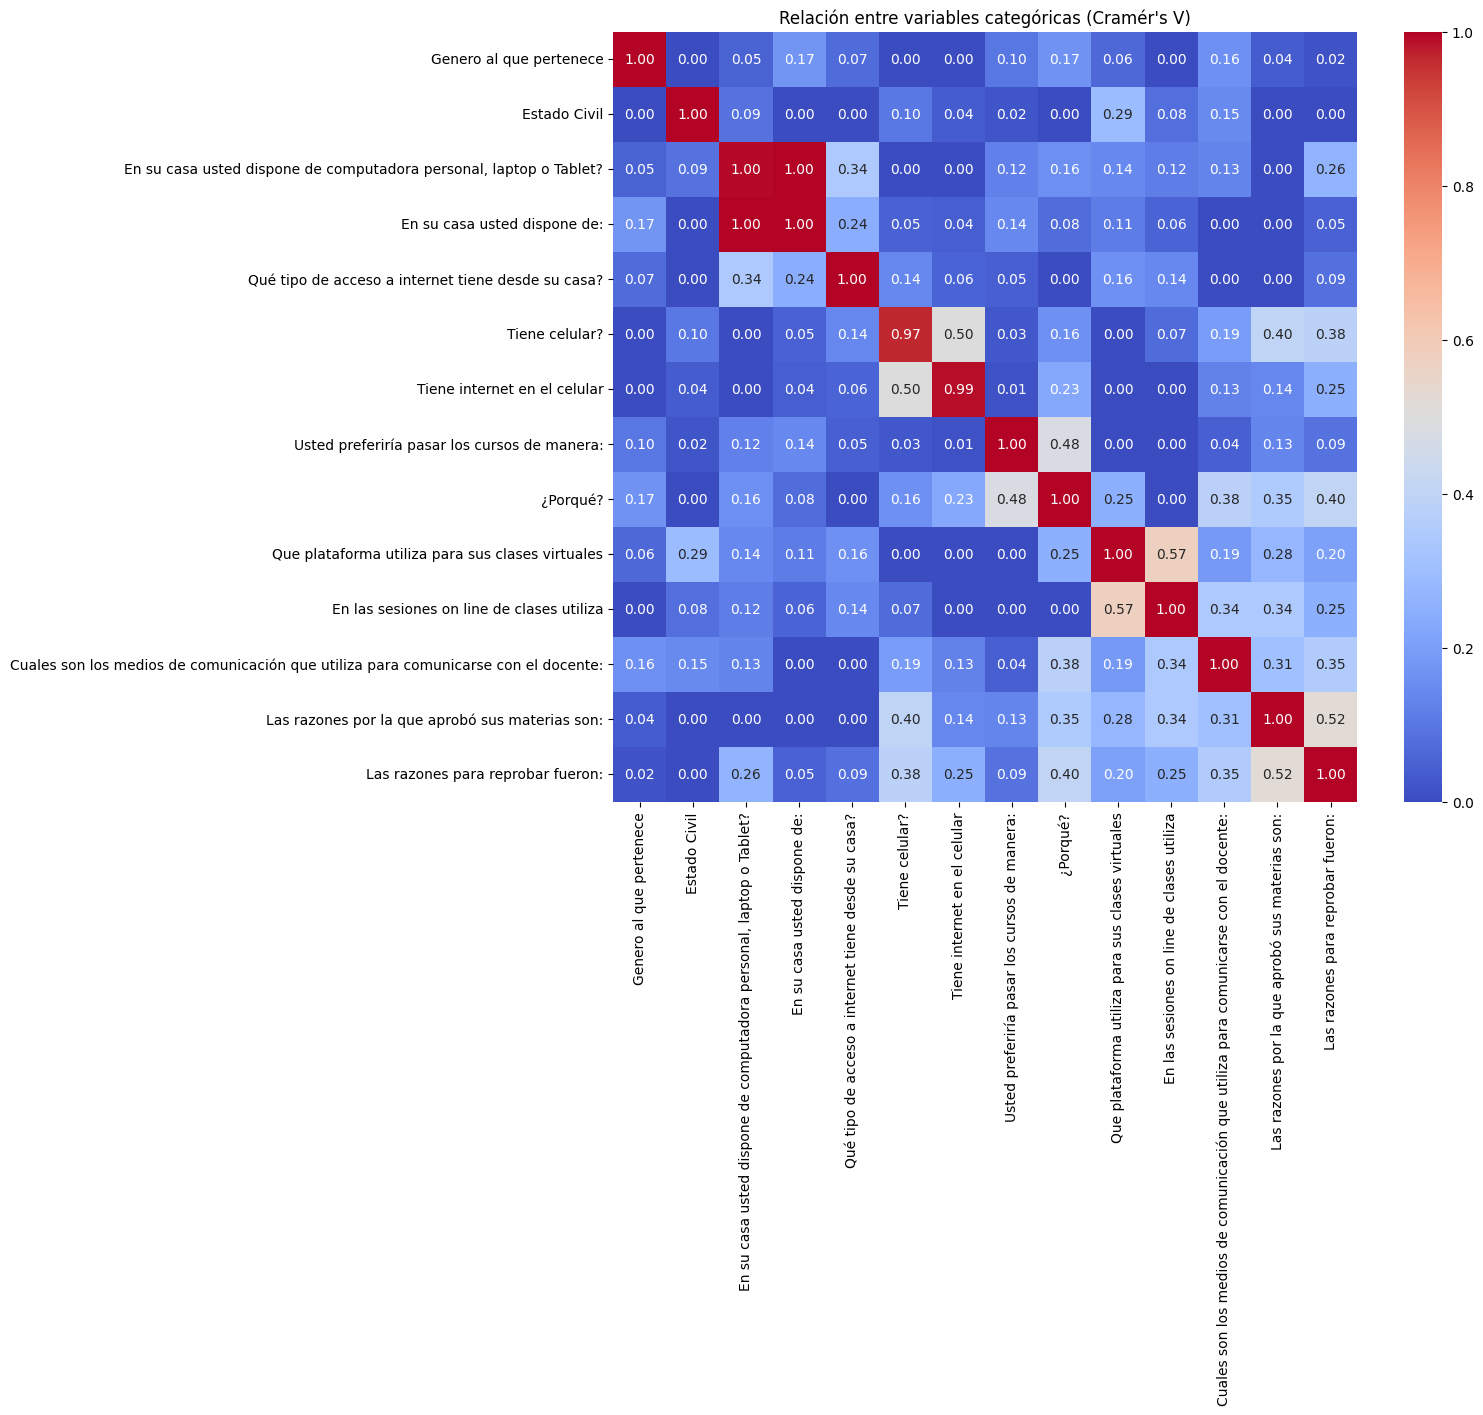

In [249]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))
sns.heatmap(matriz_cramers, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Relación entre variables categóricas (Cramér's V)")
plt.show()


Variables numéricas: ['Escriba su edad en años cumplidos', 'Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?', 'Cantidad de materias que ha tomado hasta la fecha', 'Cantidad de materias aprobadas hasta la fecha', 'Cantidad de materias reprobadas hasta la fecha.', 'El nivel de aprendizaje que ha logrado fue (donde 1 es pésimo y 5 es excelente):']


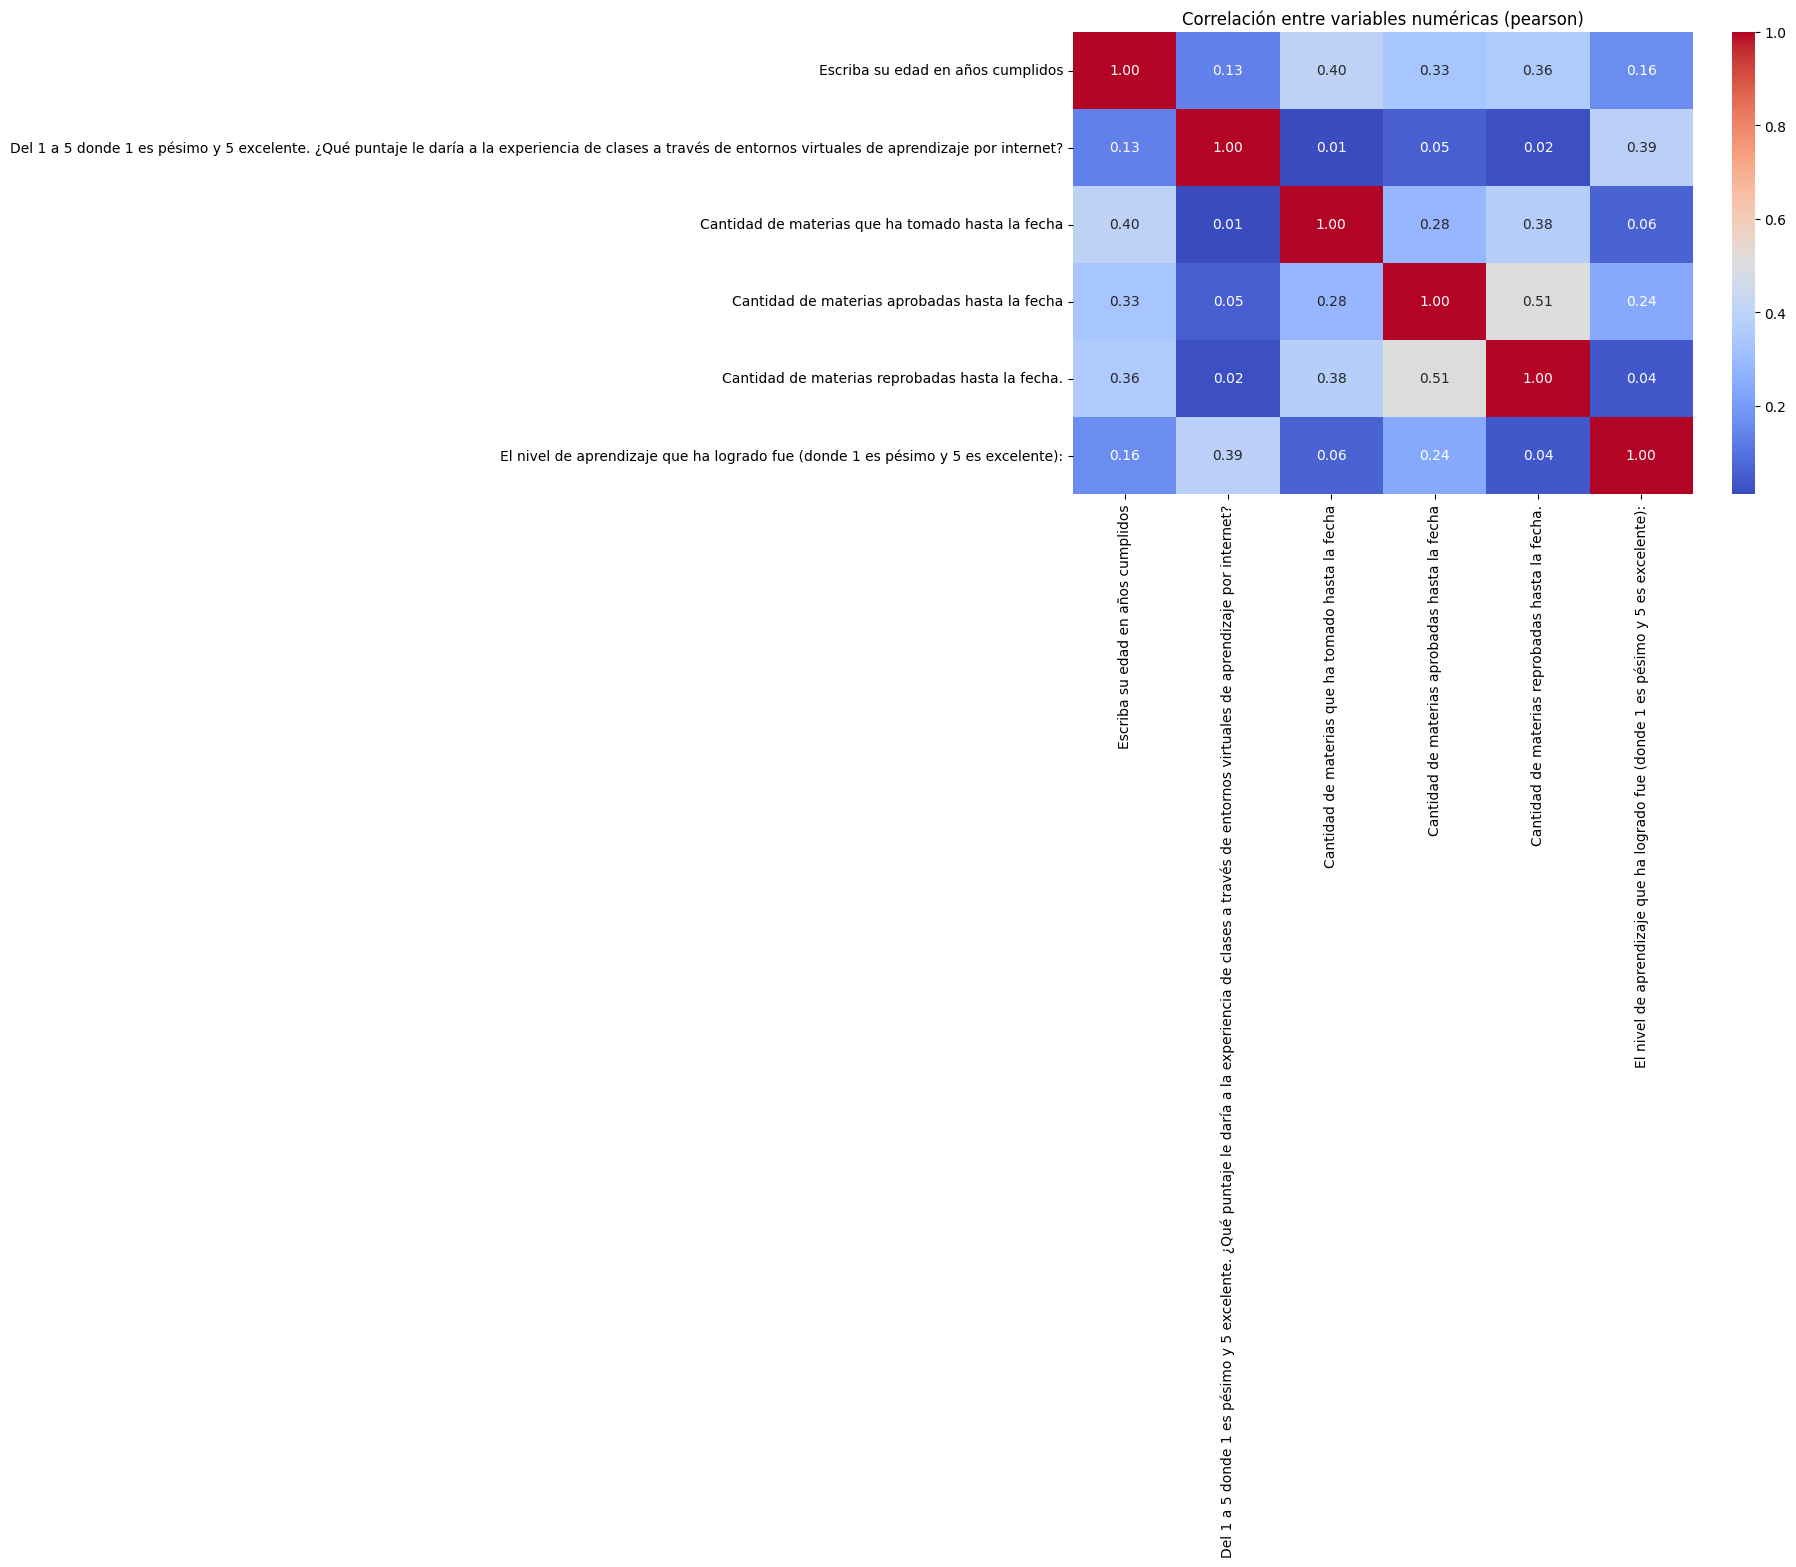

In [250]:
import pandas as pd

numericas = examen.select_dtypes(include=['float64','int']).columns.tolist()
print("Variables numéricas:", numericas)
import matplotlib.pyplot as plt
import seaborn as sns

# Calcular correlación de Spearman
matriz_corr = examen[numericas].corr(method='pearson')

# Gráfico de calor
plt.figure(figsize=(10,6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlación entre variables numéricas (pearson)")
plt.show()


Eliminacion de la columna  
**'En su casa usted dispone de computadora personal, laptop o Tablet?'**'  
y se mantendra la columna:  
**'En su casa dispone de: '** ya que esta es mas explicita

## **ELIMINACION DE COLUMNAS**

Eliminacion de la columna: **'En su casa usted dispone de:'**

In [251]:
# Eliminar la columna
examen = examen.drop(columns=['En su casa usted dispone de:'])

# Verificar que se eliminó
print(examen.columns)


Index(['Correo electrónico', 'Escriba su edad en años cumplidos',
       'Genero al que pertenece', 'Estado Civil',
       'En su casa usted dispone de computadora personal, laptop o Tablet?',
       'Qué tipo de acceso a internet tiene desde su casa?', 'Tiene celular?',
       'Tiene internet en el celular',
       'Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?',
       'Usted preferiría pasar los cursos de manera:', '¿Porqué?',
       'Que plataforma utiliza para sus clases virtuales',
       'En las sesiones on line de clases utiliza',
       'Cuales son los medios de comunicación que utiliza para comunicarse con el docente:',
       'Cantidad de materias que ha tomado hasta la fecha',
       'Cantidad de materias aprobadas hasta la fecha',
       'Las razones por la que aprobó sus materias son:',
       'Cantidad de materias reprobadas hasta la fecha.',
       'Las razones para

Eliminacion de las columnas

In [252]:
# Eliminar la columna
examen = examen.drop(columns=['Correo electrónico','Dirección de correo electrónico'])

# Verificar que se eliminó
print(examen.columns)


Index(['Escriba su edad en años cumplidos', 'Genero al que pertenece',
       'Estado Civil',
       'En su casa usted dispone de computadora personal, laptop o Tablet?',
       'Qué tipo de acceso a internet tiene desde su casa?', 'Tiene celular?',
       'Tiene internet en el celular',
       'Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?',
       'Usted preferiría pasar los cursos de manera:', '¿Porqué?',
       'Que plataforma utiliza para sus clases virtuales',
       'En las sesiones on line de clases utiliza',
       'Cuales son los medios de comunicación que utiliza para comunicarse con el docente:',
       'Cantidad de materias que ha tomado hasta la fecha',
       'Cantidad de materias aprobadas hasta la fecha',
       'Las razones por la que aprobó sus materias son:',
       'Cantidad de materias reprobadas hasta la fecha.',
       'Las razones para reprobar fueron:',
  

# **PCA REDUCCION DE LA DIMENSIONALIDAD**

In [253]:
# instalacion 
# !pip install prince

In [254]:
# -----------------------------------------------
# Librerías necesarias
# -----------------------------------------------
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import prince

# -----------------------------------------------
# 1 Separar variables numéricas y categóricas
# -----------------------------------------------
numericas = examen.select_dtypes(include=['float64', 'int']).columns.tolist()
categoricas = examen.select_dtypes(include=['object', 'category']).columns.tolist()



# Variables numéricas (solo nombre)
tabla_num = [[i+1, col] for i, col in enumerate(numericas)]

# Variables categóricas (nombre + número de categorías únicas)
categorias_por_columna = df[categoricas].nunique()
tabla_cat = [[i+1, col, categorias_por_columna[col]] for i, col in enumerate(categoricas)]

print("\n===============================")
print("Variables Numéricas")
print("===============================")
print(tabulate(tabla_num, headers=["N°", "Columna"], tablefmt="pretty"))

print("\n\n\n===============================")
print("Variables Categóricas")
print("===============================")
print(tabulate(tabla_cat, headers=["N°", "Columna", "Categorías únicas"], tablefmt="pretty"))




Variables Numéricas
+----+---------------------------------------------------------------------------------------------------------------------------------------------------------+
| N° |                                                                         Columna                                                                         |
+----+---------------------------------------------------------------------------------------------------------------------------------------------------------+
| 1  |                                                            Escriba su edad en años cumplidos                                                            |
| 2  | Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet? |
| 3  |                                                    Cantidad de materias que ha tomado hasta la fecha                                                    |
| 4  |       

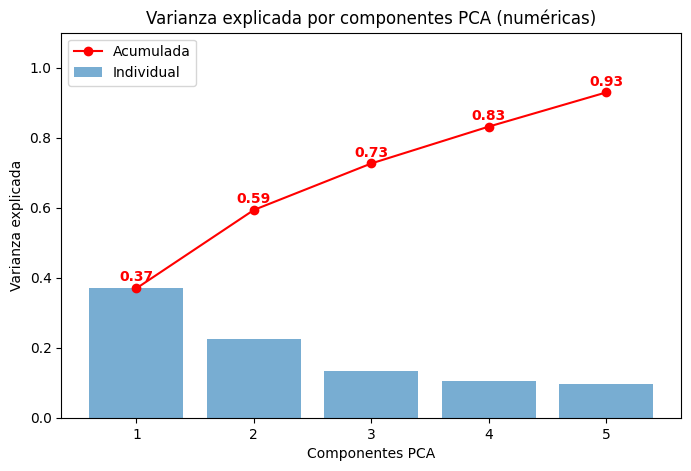

Componente  Varianza individual  Varianza acumulada
     PCA_1             0.369751            0.369751
     PCA_2             0.223862            0.593613
     PCA_3             0.132854            0.726467
     PCA_4             0.105242            0.831709
     PCA_5             0.097693            0.929402


In [255]:
# -----------------------------------------------
# PCA para variables numéricas
# -----------------------------------------------
if numericas:
    # Escalar los datos
    scaler = StandardScaler()   # standarizando los datos
    X_num = scaler.fit_transform(examen[numericas])

    # PCA
    pca = PCA(n_components=min(len(numericas),5))  # hasta 5 componentes o menos
    X_pca = pca.fit_transform(X_num)

    # Varianza explicada
    var_exp = pca.explained_variance_ratio_
    cum_var_exp = var_exp.cumsum()

    # Gráfico de varianza
    plt.figure(figsize=(8,5))
    plt.bar(range(1, len(var_exp)+1), var_exp, alpha=0.6, label='Individual')
    plt.plot(range(1, len(cum_var_exp)+1), cum_var_exp, marker='o', color='red', label='Acumulada')

    # Añadir números encima de cada punto de varianza acumulada
    for i, v in enumerate(cum_var_exp):
        plt.text(i+1, v + 0.02, f"{v:.2f}", ha='center', color='red', fontweight='bold')

    plt.xlabel('Componentes PCA')
    plt.ylabel('Varianza explicada')
    plt.title('Varianza explicada por componentes PCA (numéricas)')
    plt.ylim(0, 1.1)  # para que los números no se salgan del gráfico
    plt.legend()
    plt.show()

    # Crear DataFrame con componentes
    df_pca = pd.DataFrame(X_pca, columns=[f"PCA_{i+1}" for i in range(X_pca.shape[1])])

    # Mostrar tabla con varianza individual y acumulada
    df_var = pd.DataFrame({
        "Componente": [f"PCA_{i+1}" for i in range(len(var_exp))],
        "Varianza individual": var_exp,
        "Varianza acumulada": cum_var_exp
    })
    print(df_var.to_string(index=False))

else:
    df_pca = pd.DataFrame()
    print("No hay variables numéricas para PCA.")


In [256]:
examen.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 909 entries, 0 to 908
Data columns (total 19 columns):
 #   Column                                                                                                                                                   Non-Null Count  Dtype  
---  ------                                                                                                                                                   --------------  -----  
 0   Escriba su edad en años cumplidos                                                                                                                        909 non-null    Int64  
 1   Genero al que pertenece                                                                                                                                  909 non-null    object 
 2   Estado Civil                                                                                                                                             909 non-n

# **10) CONVERSION VARIABLES CATEGORICAS**

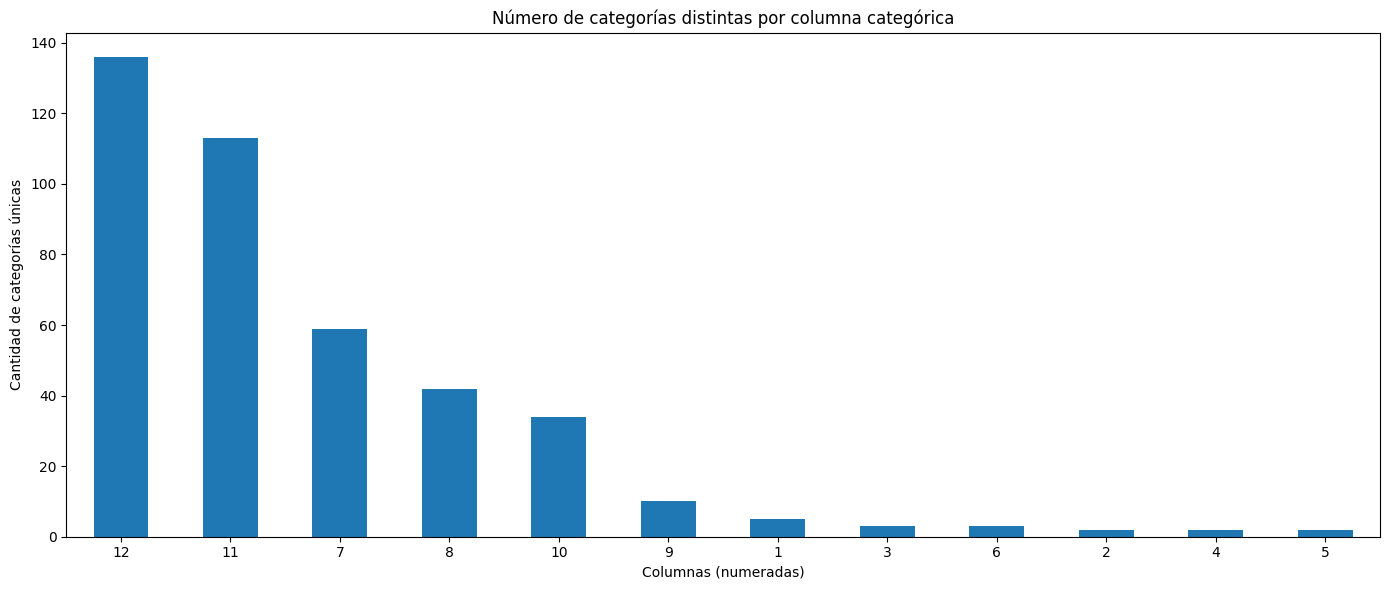


Tabla de equivalencias
+----+------------------------------------------------------------------------------------+-------------------+
| N° |                                      Columna                                       | Categorías únicas |
+----+------------------------------------------------------------------------------------+-------------------+
| 1  |                                    Estado Civil                                    |         5         |
| 2  |         En su casa usted dispone de computadora personal, laptop o Tablet?         |         2         |
| 3  |                 Qué tipo de acceso a internet tiene desde su casa?                 |         3         |
| 4  |                                   Tiene celular?                                   |         2         |
| 5  |                            Tiene internet en el celular                            |         2         |
| 6  |                    Usted preferiría pasar los cursos de manera:          

In [257]:
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

# -------------------------------------------------
# 1. Columnas a excluir
# -------------------------------------------------
#excluir = ['Correo electrónico', 'Dirección de correo electrónico']

# Crear copia sin las columnas excluidas
df = examen #.drop(columns=excluir)

# -------------------------------------------------
# 2. Detectar columnas categóricas
# -------------------------------------------------
# Seleccionar columnas object
cat_cols = df.select_dtypes(include=['object']).columns

# Excluir la columna "Género al que pertenece"
cat_cols = [col for col in cat_cols if col != "Genero al que pertenece"]


# Contar categorías por columna
categorias_por_columna = df[cat_cols].nunique()

# Crear un diccionario: número → columna
mapa_numeros = {i+1: col for i, col in enumerate(categorias_por_columna.index)}

# Crear serie con índices numéricos
categorias_numeradas = categorias_por_columna.copy()
categorias_numeradas.index = list(mapa_numeros.keys())

# -------------------------------------------------
# 3. Gráfico
# -------------------------------------------------
plt.figure(figsize=(14,6))
categorias_numeradas.sort_values(ascending=False).plot(kind='bar')
plt.title('Número de categorías distintas por columna categórica')
plt.ylabel('Cantidad de categorías únicas')
plt.xlabel('Columnas (numeradas)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 4. Mostrar equivalencias con tabla ordenada
# -------------------------------------------------
tabla = []

for numero, columna in mapa_numeros.items():
    cantidad = categorias_por_columna[columna]
    tabla.append([numero, columna, cantidad])

print("\n===============================")
print("Tabla de equivalencias")
print("===============================")
print(tabulate(tabla, headers=["N°", "Columna", "Categorías únicas"], tablefmt="pretty"))


In [258]:
!pip install termcolor



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [259]:
from termcolor import colored
from tabulate import tabulate

# -------------------------------------------------
# 4. Clasificar columnas por cardinalidad
# -------------------------------------------------
# Seleccionar columnas de baja cardinalidad
low_card = categorias_por_columna[categorias_por_columna <= 10].index.tolist()

# Excluir "Género al que pertenece"
low_card = [col for col in low_card if col != "Genero al que pertenece"]

mid_card = categorias_por_columna[(categorias_por_columna > 10) &
                                  (categorias_por_columna < 100)].index.tolist()
high_card = categorias_por_columna[categorias_por_columna >= 100].index.tolist()

print("\n" + "="*60)
print(colored("CLASIFICACIÓN DE COLUMNAS POR CARDINALIDAD", 'cyan', attrs=['bold']))
print("="*60 + "\n")

# -------------------------------------------------
# Crear tabla de resumen
# -------------------------------------------------
tabla_resumen = []

for col in low_card:
    tabla_resumen.append([col, categorias_por_columna[col], "One-Hot Encoding (baja cardinalidad)"])

for col in mid_card:
    tabla_resumen.append([col, categorias_por_columna[col], "Frequency Encoding (cardinalidad media)"])

for col in high_card:
    tabla_resumen.append([col, categorias_por_columna[col], "Hashing/Binary Encoding (alta cardinalidad)"])

# Imprimir tabla
print(colored("Resumen general de la asignación del método", "magenta", attrs=["bold"]))
print(tabulate(tabla_resumen,
               headers=["Columna", "Categorías", "Método recomendado"],
               tablefmt="pretty"))

# -------------------------------------------------
# Mostrar listas separadas con colores
# -------------------------------------------------
print("\n" + colored("Baja cardinalidad (≤10) → One-Hot Encoding", "green", attrs=["bold"]))
print(tabulate([[col, categorias_por_columna[col]] for col in low_card],
               headers=["Columna", "Categorías"],
               tablefmt="pretty"))

print("\n" + colored("Media cardinalidad (10–100) → Frequency Encoding", "yellow", attrs=["bold"]))
print(tabulate([[col, categorias_por_columna[col]] for col in mid_card],
               headers=["Columna", "Categorías"],
               tablefmt="pretty"))

print("\n" + colored("Alta cardinalidad (≥100) → Hashing/Binary Encoding", "red", attrs=["bold"]))
print(tabulate([[col, categorias_por_columna[col]] for col in high_card],
               headers=["Columna", "Categorías"],
               tablefmt="pretty"))



CLASIFICACIÓN DE COLUMNAS POR CARDINALIDAD

Resumen general de la asignación del método
+------------------------------------------------------------------------------------+------------+---------------------------------------------+
|                                      Columna                                       | Categorías |             Método recomendado              |
+------------------------------------------------------------------------------------+------------+---------------------------------------------+
|                                    Estado Civil                                    |     5      |    One-Hot Encoding (baja cardinalidad)     |
|         En su casa usted dispone de computadora personal, laptop o Tablet?         |     2      |    One-Hot Encoding (baja cardinalidad)     |
|                 Qué tipo de acceso a internet tiene desde su casa?                 |     3      |    One-Hot Encoding (baja cardinalidad)     |
|                                  

In [260]:
# -------------------------------------------------
# 5. Crear copia para codificar
# -------------------------------------------------
df_encoded = df.copy()
print(f"Cantidad de columnas antes de codificar: {df_encoded.shape[1]}")

# -------------------------------------------------
# 6. One-Hot Encoding (≤10 categorías)
# -------------------------------------------------
# pd.get_dummies por defecto crea 0/1, aseguramos dtype int
df_encoded = pd.get_dummies(df_encoded, columns=low_card, drop_first=False, dtype=int)

# -------------------------------------------------
# 7. Frequency Encoding (10–60 categorías)
# -------------------------------------------------
for col in mid_card:
    freqs = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freqs)

# -------------------------------------------------
# 8. High Cardinality (≥100 categorías)
#     Agrupar categorías raras (<1%) + Frequency Encoding
# -------------------------------------------------
for col in high_card:
    # 8a. Agrupar categorías raras
    freqs = df_encoded[col].value_counts(normalize=True)
    rare = freqs[freqs < 0.01].index
    df_encoded[col] = df_encoded[col].replace(rare, 'OTRO')

    # 8b. Frequency encoding final
    freqs2 = df_encoded[col].value_counts(normalize=True)
    df_encoded[col] = df_encoded[col].map(freqs2)

# -------------------------------------------------
# 9. Resultado final
# -------------------------------------------------
print(f"Cantidad de columnas después de codificar: {df_encoded.shape[1]}")
df_encoded.head()


Cantidad de columnas antes de codificar: 19
Cantidad de columnas después de codificar: 39


,Escriba su edad en años cumplidos,Genero al que pertenece,Del 1 a 5 donde 1 es pésimo y 5 excelente. ¿Qué puntaje le daría a la experiencia de clases a través de entornos virtuales de aprendizaje por internet?,¿Porqué?,Que plataforma utiliza para sus clases virtuales,Cuales son los medios de comunicación que utiliza para comunicarse con el docente:,Cantidad de materias que ha tomado hasta la fecha,Cantidad de materias aprobadas hasta la fecha,Las razones por la que aprobó sus materias son:,Cantidad de materias reprobadas hasta la fecha.,...,En las sesiones on line de clases utiliza_Jitsi Meet,En las sesiones on line de clases utiliza_Meet de Google,"En las sesiones on line de clases utiliza_Meet de Google, Jitsi Meet",En las sesiones on line de clases utiliza_Teams,En las sesiones on line de clases utiliza_Zoom Meet,"En las sesiones on line de clases utiliza_Zoom Meet, Jitsi Meet","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google, Jitsi Meet","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google, Jitsi Meet, Teams","En las sesiones on line de clases utiliza_Zoom Meet, Meet de Google, Teams"
0,55,Masculino,3,0.272827,0.001100,0.001100,40.0,50,0.125413,60.0,...,1,0,0,0,0,0,0,0,0,0
1,24,Masculino,3,0.311331,0.597360,0.271727,13.0,42,0.012101,5.0,...,0,0,0,0,0,0,1,0,0,0
2,20,Masculino,1,0.311331,0.326733,0.225523,10.0,2,0.125413,16.0,...,0,1,0,0,0,0,0,0,0,0
3,18,Masculino,2,0.311331,0.597360,0.193619,7.0,0,0.246425,0.0,...,0,1,0,0,0,0,0,0,0,0
4,24,Masculino,1,0.311331,0.326733,0.271727,13.0,1,0.246425,6.0,...,0,0,0,0,0,0,1,0,0,0


In [263]:
df_encoded.to_csv("data/modelos/datos_prepro_examen_respuestas.csv", index=False, encoding="utf-8")


#

In [262]:

df_encoded.dtypes.value_counts()


int64      28
float64     6
Int64       3
object      1
Float64     1
Name: count, dtype: int64